# Análisis Exploratorio de Datos (EDA): Caracterización del Corpus TUSZ y Topología del Espacio de Características

<style>
/* Estilo para el "Título Fantasma" (Fake H3) */
.fake-h3 {
    font-size: 1.5rem !important; /* Tamaño de un h3 */
    font-weight: 700 !important;   /* Negrita fuerte */
    color: #2c3e50 !important;    /* Color oscuro profesional */
    margin-top: 2rem !important;  /* Espaciado superior */
    margin-bottom: 1rem !important; /* Espaciado inferior */
    display: block;               /* Se comporta como bloque */
    font-family: sans-serif;
}

/* El resto de tu CSS (el de los botones y gráficos) se queda igual abajo... */
</style>

In [1]:
import os
import sys
from IPython.display import display, HTML
import pandas as pd

project_root = r"D:\TUSZ_project"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    os.chdir(src_path)
    
from eeg_analysis import (
    plot_demographics, plot_sessions, plot_integrity_1020,
    plot_initial_audit, plot_exclusion,
    get_initial_audit, estimate_average_ictal_durations,
    create_sample, get_top_features_ranking,
    plot_spearman_heatmap, plot_pca_rank, plot_umap, plot_umap_3d,
    run_kruskal, plot_topomap, plot_kde,
    plot_seizure, get_train_audit, plot_train_comparison, render_embedded_image
)

# Introducción

El electroencefalograma (EEG), debido a su alta resolución temporal, constituye la herramienta estándar para el diagnóstico y monitoreo de la epilepsia. En los últimos años, el desarrollo de modelos de aprendizaje automático ha permitido automatizar la detección de patrones ictales; sin embargo, la robustez de estos enfoques depende estrictamente de la disponibilidad de grandes volúmenes de datos clínicos reales. En este escenario, el Temple University Hospital EEG Corpus (TUH EEG), y específicamente el Temple University Seizure Corpus (TUSZ), se consolidan como recursos fundamentales al proporcionar registros anotados de crisis epilépticas en un entorno clínico no controlado.

No obstante, el uso de datos provenientes de la práctica clínica real introduce desafíos significativos, tales como la variabilidad en los montajes de electrodos y el marcado desbalance entre las clases de crisis. Por consiguiente, el Análisis Exploratorio de Datos (EDA) en esta investigación no es solo un paso descriptivo, sino una fase crítica de validación. Su propósito es caracterizar la estructura del corpus, asegurar la integridad de las señales y garantizar que la distribución de los eventos sea estadísticamente representativa antes de proceder con la extracción de características y el entrenamiento de los modelos predictivos.

:::{admonition} Nota Metodológica: The TUH Seizure Corpus (TUSZ)
:class: note

El Corpus TUSZ (v.2.0.3) constituye el repositorio público de crisis epilépticas más extenso y riguroso disponible en la actualidad. Proveniente del Hospital de la Universidad de Temple en **Estados Unidos**, este conjunto de datos comprende un total de 5,042 registros pertenecientes a 675 pacientes únicos ([Shah et al., 2018](https://doi.org/10.3389/fninf.2018.00083)). Una característica fundamental de este corpus es que no se limita a una demografía específica; por el contrario, incluye registros de pacientes en **todas las etapas del desarrollo humano** (desde población pediátrica hasta geriátrica), proporcionando una variabilidad biológica y patológica altamente representativa de la realidad clínica.

La magnitud de esta base de datos se refleja en sus más de 900 horas de grabación, abarcando desde estudios ambulatorios breves hasta monitoreos prolongados en unidades de cuidados intensivos, lo que permite capturar la evolución temporal completa de los eventos ictales y sus fases circundantes. Un aspecto técnico decisivo es que la totalidad del conjunto de datos ha sido etiquetada manualmente por neurólogos especialistas. Estas anotaciones definen los tiempos de inicio y finalización de cada episodio y clasifican los eventos en categorías clínicas estructuradas (crisis focales, generalizadas y no especificadas), proporcionando una base de verdad (*ground truth*) validada bajo estándares profesionales para diferenciar sistemáticamente entre diversas manifestaciones electrofisiológicas.
:::

El propósito general de este proyecto es desarrollar un sistema de monitoreo inteligente capaz de clasificar tres macroclases fundamentales de eventos electroencefalográficos (basal, crisis focales y crisis generalizadas), diseñado específicamente para su integración en entornos hospitalarios. Este sistema no solo busca alcanzar una alta precisión diagnóstica, sino que prioriza la interpretabilidad de sus decisiones, proporcionando a los clínicos herramientas visuales y estadísticas que sustenten las alertas generadas. A continuación, se presenta el diagrama general que ilustra las etapas de procesamiento, desde la adquisición de la señal hasta la visualización interpretativa de los resultados de clasificación:


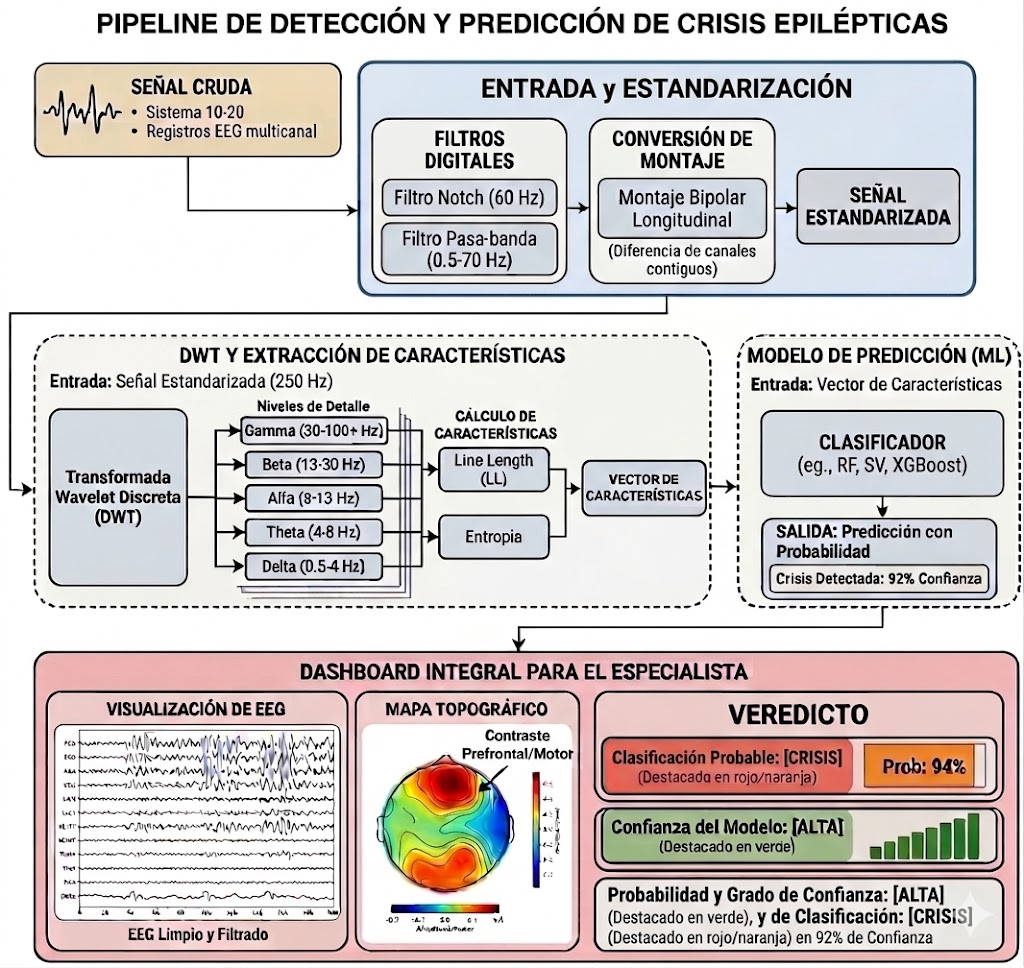

In [2]:
from IPython.display import display, HTML
target_image = r"D:\TUSZ_project\_static\flow_diagram.jpg"
display(HTML(render_embedded_image(target_image)))

# Arquitectura de Datos

La base de datos consolidada para esta investigación presenta una robustez estadística significativa, fundamentada en un total de 675 pacientes únicos y un volumen de registro acumulado de 1,240.27 horas. Esta magnitud de datos no solo asegura una cobertura amplia de eventos ictales, sino que garantiza que el modelo sea expuesto a una variabilidad biológica real, propia de un entorno clínico no controlado. Al analizar la cronología de los sujetos, y tras la exclusión de inconsistencias en los metadatos (valores 0 y 999), se identificó un rango etario que se extiende desde los 0 hasta los 89 años, confirmando la naturaleza polivalente del corpus al incluir desde neonatos hasta adultos mayores. Esta diversidad es crucial para el desarrollo de un sistema de monitoreo capaz de adaptarse a los cambios neurofisiológicos que ocurren a lo largo de todo el ciclo vital. Las particularidades de la distribución de edad y la composición por género se resumen y visualizan en las siguientes gráficas:


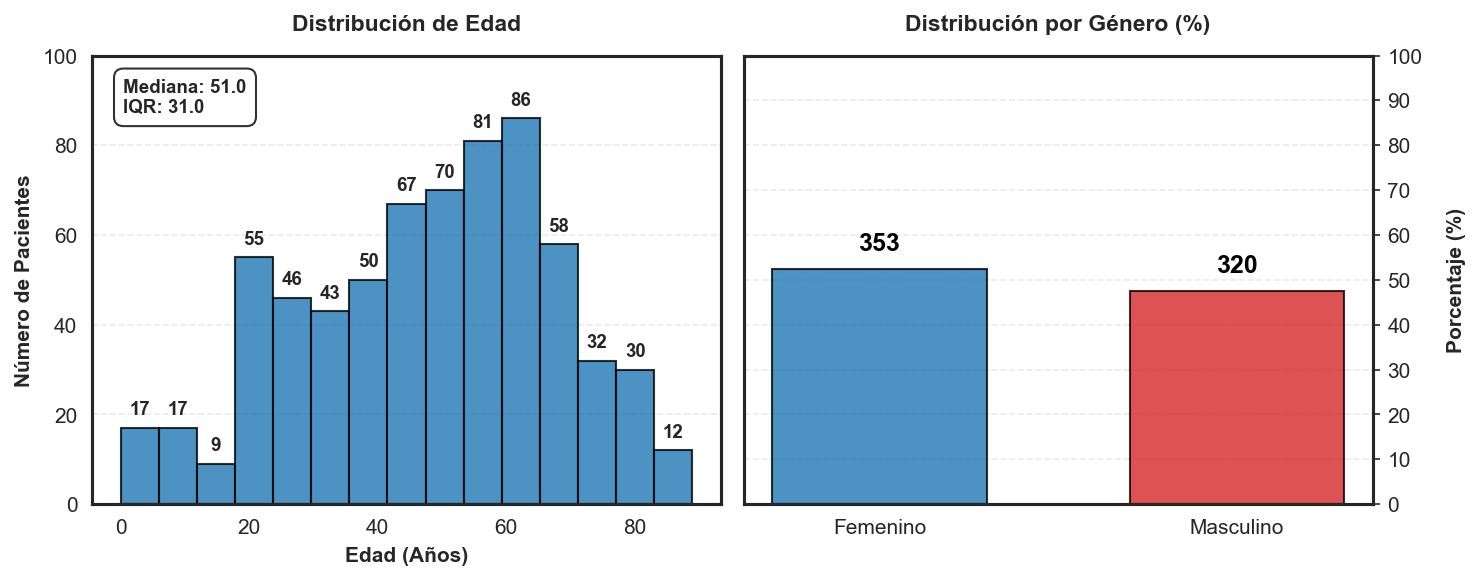

In [2]:
PATH_META_PATIENTS = r"D:\TUSZ_project\TUSZ_DataLake\02_Metadata\metadata_patients.parquet"
plot_demographics(PATH_META_PATIENTS)

La inspección de las distribuciones demográficas permite identificar dos fortalezas críticas para el entrenamiento del modelo. En primer lugar, se observa que una parte predominante de los pacientes se sitúa en la etapa adulta y adulta mayor, lo que proporciona una base sólida de patrones electrofisiológicos maduros. En segundo lugar, existe un balance de género notable (353 pacientes femeninos vs. 320 masculinos), un factor determinante que mitiga el riesgo de sesgo de género en la clasificación. Este equilibrio permite que el sistema desarrolle una mayor resistencia ante las variables biológicas inherentes a los circuitos neurológicos de ambos sexos, garantizando que las características extraídas (como la entropía o la longitud de línea) sean representativas de la arquitectura cerebral humana en su sentido más amplio y no de un subgrupo específico.

Por otro lado, la infraestructura técnica de los registros analizados refleja una evolución tecnológica significativa en la práctica clínica, con un periodo de recolección validado que se extiende desde el año 2000 hasta el 2019. En términos de digitalización, el corpus presenta una frecuencia de muestreo predominante de 256.0 Hz, acompañada de una configuración de filtrado analógico base con un paso-alto de 0.0 Hz y un paso-bajo de 128.0 Hz. Esta heterogeneidad en los parámetros de adquisición de hardware a lo largo de dos décadas subraya la relevancia del módulo de pre-procesamiento del sistema propuesto, el cual homogeneiza las señales para garantizar que el predictor sea robusto ante las diferencias en los equipos de grabación hospitalarios. Los detalles sobre la distribución de estas configuraciones técnicas se resumen en la siguiente gráfica:


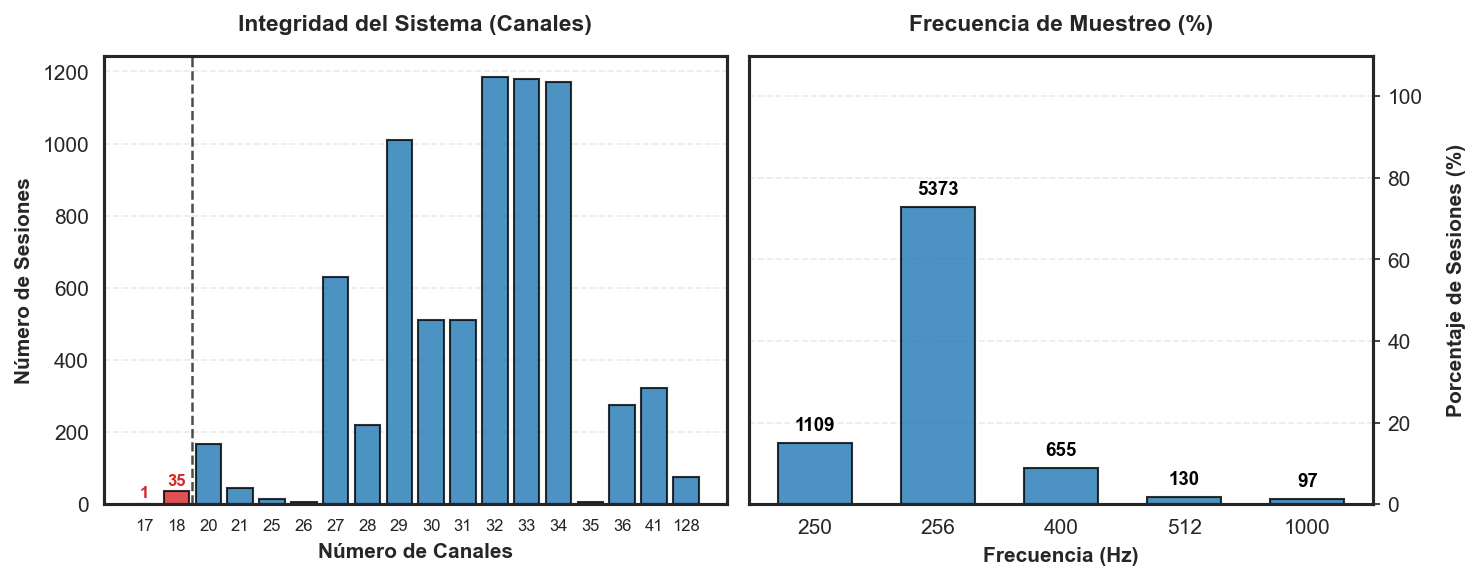

In [3]:
PATH_META_SESSIONS = r"D:\TUSZ_project\TUSZ_DataLake\02_Metadata\metadata_sessions.parquet"
plot_sessions(PATH_META_SESSIONS)

El análisis de las anotaciones y configuraciones del corpus revela un escenario de alta complejidad técnica y diagnóstica. Por un lado, se observa una dispersión importante en la disposición física de los electrodos entre los registros; aunque predominan los montajes referenciales (01_tcp_ar y 03_tcp_ar_a), estos coexisten con configuraciones bipolares (02_tcp_le), lo que introduce una variabilidad en la morfología de la señal que debe ser resuelta en etapas posteriores. Por otro lado, aunque el TUSZ proporciona una riqueza excepcional con más de 8 tipos específicos de crisis ictales, la distribución de los datos presenta un desbalance de clase crítico. Como se visualiza en la caracterización de los eventos, la clase basal (bckg), que corresponde a periodos sin actividad epiléptica, domina abrumadoramente el conjunto de datos con más de 1.7 millones de segundos. Este marcado contraste entre la abundancia de señales de fondo y la relativa escasez de eventos de crisis (como fnsz y gnsz) constituye el principal desafío para el entrenamiento del sistema, exigiendo un modelo con una alta capacidad de discriminación.


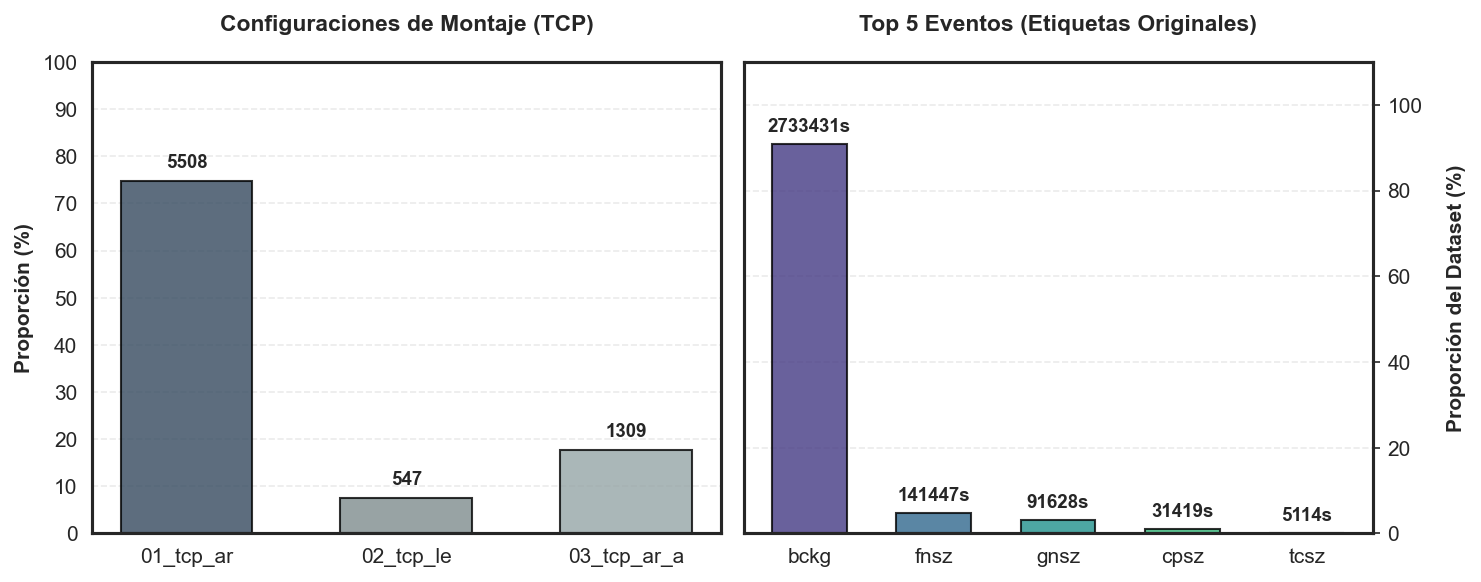

In [6]:
CSV_PATH = r"D:\TUSZ_project\TUSZ_DataLake\01_Raw_Consolidated"
df = get_initial_audit(CSV_PATH, PATH_META_PATIENTS)
plot_initial_audit(PATH_META_SESSIONS, df)

Finalmente, para concluir esta fase de caracterización técnica, se realiza un desglose cuantitativo de la naturaleza temporal de los eventos ictales remanentes en el corpus TUSZ tras el proceso de depuración. La siguiente tabla sintetiza la distribución de cada etiqueta clínica, detallando tanto su duración acumulada en segundos como su respectiva proporción dentro del conjunto de datos, proporcionando una visión integral del escenario de desbalance estructural que el sistema de clasificación deberá enfrentar en las etapas de entrenamiento:

In [218]:
df_audit = df.reset_index().rename(columns={'index': 'Acrónimo', 'Label': 'Acrónimo'})
dicc_nombres_tusz = {
    'bckg': 'Actividad Basal',
    'fnsz': 'Crisis Focal No Específica',
    'gnsz': 'Crisis Generalizada No Específica',
    'cpsz': 'Crisis Parcial Compleja',
    'tcsz': 'Crisis Tónico-Clónica',
    'spsz': 'Crisis Parcial Simple',
    'mysz': 'Crisis Mioclónica',
    'absz': 'Crisis de Ausencia',
    'tnsz': 'Crisis Tónica'
}

df_audit['Descripción Clínica'] = df_audit['Acrónimo'].map(dicc_nombres_tusz)
df_audit = df_audit[['Acrónimo', 'Descripción Clínica', 'Segundos', 'Prop (%)']]

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_audit = {
    "Segundos": lambda x: smart_format(x, "{:,.0f}"),
    "Prop (%)": lambda x: smart_format(x, "{:.2f}%")
}

styled_audit = df_audit.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), 
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), 
                                  ('color', 'black'), ('font-weight', 'bold'), 
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), 
                                  ('padding', '10px')]}
])

styled_audit = styled_audit.format(format_dict_audit)
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_audit.to_html() + "</div>"))

Acrónimo,Descripción Clínica,Segundos,Prop (%)
bckg,Actividad Basal,"2,733,432",90.88%
fnsz,Crisis Focal No Específica,"141,448",4.70%
gnsz,Crisis Generalizada No Específica,"91,628",3.05%
cpsz,Crisis Parcial Compleja,"31,419",1.04%
tcsz,Crisis Tónico-Clónica,"5,115",0.17%
spsz,Crisis Parcial Simple,"1,942",0.06%
mysz,Crisis Mioclónica,"1,293",0.04%
absz,Crisis de Ausencia,896,0.03%
tnsz,Crisis Tónica,641,0.02%


Complementariamente, el análisis de la distribución temporal revela que la duración de los eventos ictales es profundamente heterogénea, lo que hace imperativo caracterizar el rango de extensión de cada clase para consolidar criterios de etiquetado técnicamente sólidos. Como se observa en la siguiente tabla, la coexistencia de crisis extremadamente breves —con medianas inferiores a los 10 segundos como en las de ausencia ($absz$)— junto a episodios paroxísticos que pueden prolongarse durante varios minutos en las categorías focales y generalizadas, plantea un reto crítico para la segmentación del sistema. Identificar estos umbrales mínimos y máximos es un paso esencial para diseñar una estrategia de ventanas de análisis que no diluya la información en eventos cortos ni fragmente excesivamente las crisis de larga duración, garantizando así la coherencia de la verdad de campo en las fases subsiguientes del modelo.

In [10]:
time = estimate_average_ictal_durations(CSV_PATH, PATH_META_PATIENTS)
df_audit = time.reset_index().rename(columns={'Label': 'Acrónimo', 'index': 'Acrónimo'})

dicc_nombres_tusz = {
    'bckg': 'Actividad Basal',
    'fnsz': 'Crisis Focal No Específica',
    'gnsz': 'Crisis Generalizada No Específica',
    'cpsz': 'Crisis Parcial Compleja',
    'tcsz': 'Crisis Tónico-Clónica',
    'spsz': 'Crisis Parcial Simple',
    'mysz': 'Crisis Mioclónica',
    'absz': 'Crisis de Ausencia',
    'tnsz': 'Crisis Tónica'
}

df_audit['Descripción Clínica'] = df_audit['Acrónimo'].map(dicc_nombres_tusz)

df_audit = df_audit.rename(columns={
    'N_Eventos': 'N eventos',
    'Mediana_Seg': 'Mediana (seg)',
    'Promedio_Seg': 'Promedio (seg)',
    'Min_Seg': 'Mínimo (seg)',
    'Max_Seg': 'Máximo (seg)'
})

cols_order = [
    'Acrónimo', 'Descripción Clínica', 'N eventos', 
    'Mediana (seg)', 'Promedio (seg)', 'Mínimo (seg)', 'Máximo (seg)'
]
df_audit = df_audit[cols_order]

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_audit = {
    "N eventos": lambda x: smart_format(x, "{:,.0f}"),
    "Mediana (seg)": lambda x: smart_format(x, "{:.2f}"),
    "Promedio (seg)": lambda x: smart_format(x, "{:.2f}"),
    "Mínimo (seg)": lambda x: smart_format(x, "{:.2f}"),
    "Máximo (seg)": lambda x: smart_format(x, "{:,.2f}")
}

styled_audit = df_audit.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), 
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), 
                                  ('color', 'black'), ('font-weight', 'bold'), 
                                  ('border', '1px solid black'), ('padding', '10px'),
                                  ('font-family', 'serif')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), 
                                  ('padding', '10px')]}
])

styled_audit = styled_audit.format(format_dict_audit)
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_audit.to_html() + "</div>"))

Acrónimo,Descripción Clínica,N eventos,Mediana (seg),Promedio (seg),Mínimo (seg),Máximo (seg)
mysz,Crisis Mioclónica,3,686.87,659.92,606.00,686.89
cpsz,Crisis Parcial Compleja,"1,520",63.15,72.04,2.34,"1,303.00"
tcsz,Crisis Tónico-Clónica,199,50.58,79.86,12.89,"2,344.05"
gnsz,Crisis Generalizada No Específica,"2,495",43.27,66.53,2.57,"2,448.00"
fnsz,Crisis Focal No Específica,"4,904",35.76,59.14,1.98,"3,601.00"
spsz,Crisis Parcial Simple,57,33.82,40.23,20.14,97.06
tnsz,Crisis Tónica,126,17.09,19.33,5.77,146.89
absz,Crisis de Ausencia,121,6.50,7.86,2.36,26.43


Con el propósito de ilustrar la manifestación morfológica de los eventos críticos en la señal electroencefalográfica procesada, se presenta a continuación un registro detallado de una transición ictal. El siguiente gráfico extrae un segmento de 10 segundos correspondiente a los primeros tres canales de una sesión del Paciente 1. En él, se visualiza con nitidez el cambio de patrón desde una actividad de fondo hacia una crisis de tipo Parcial Compleja (CPSZ), resaltando el inicio del evento paroxístico mediante una línea vertical punteada.


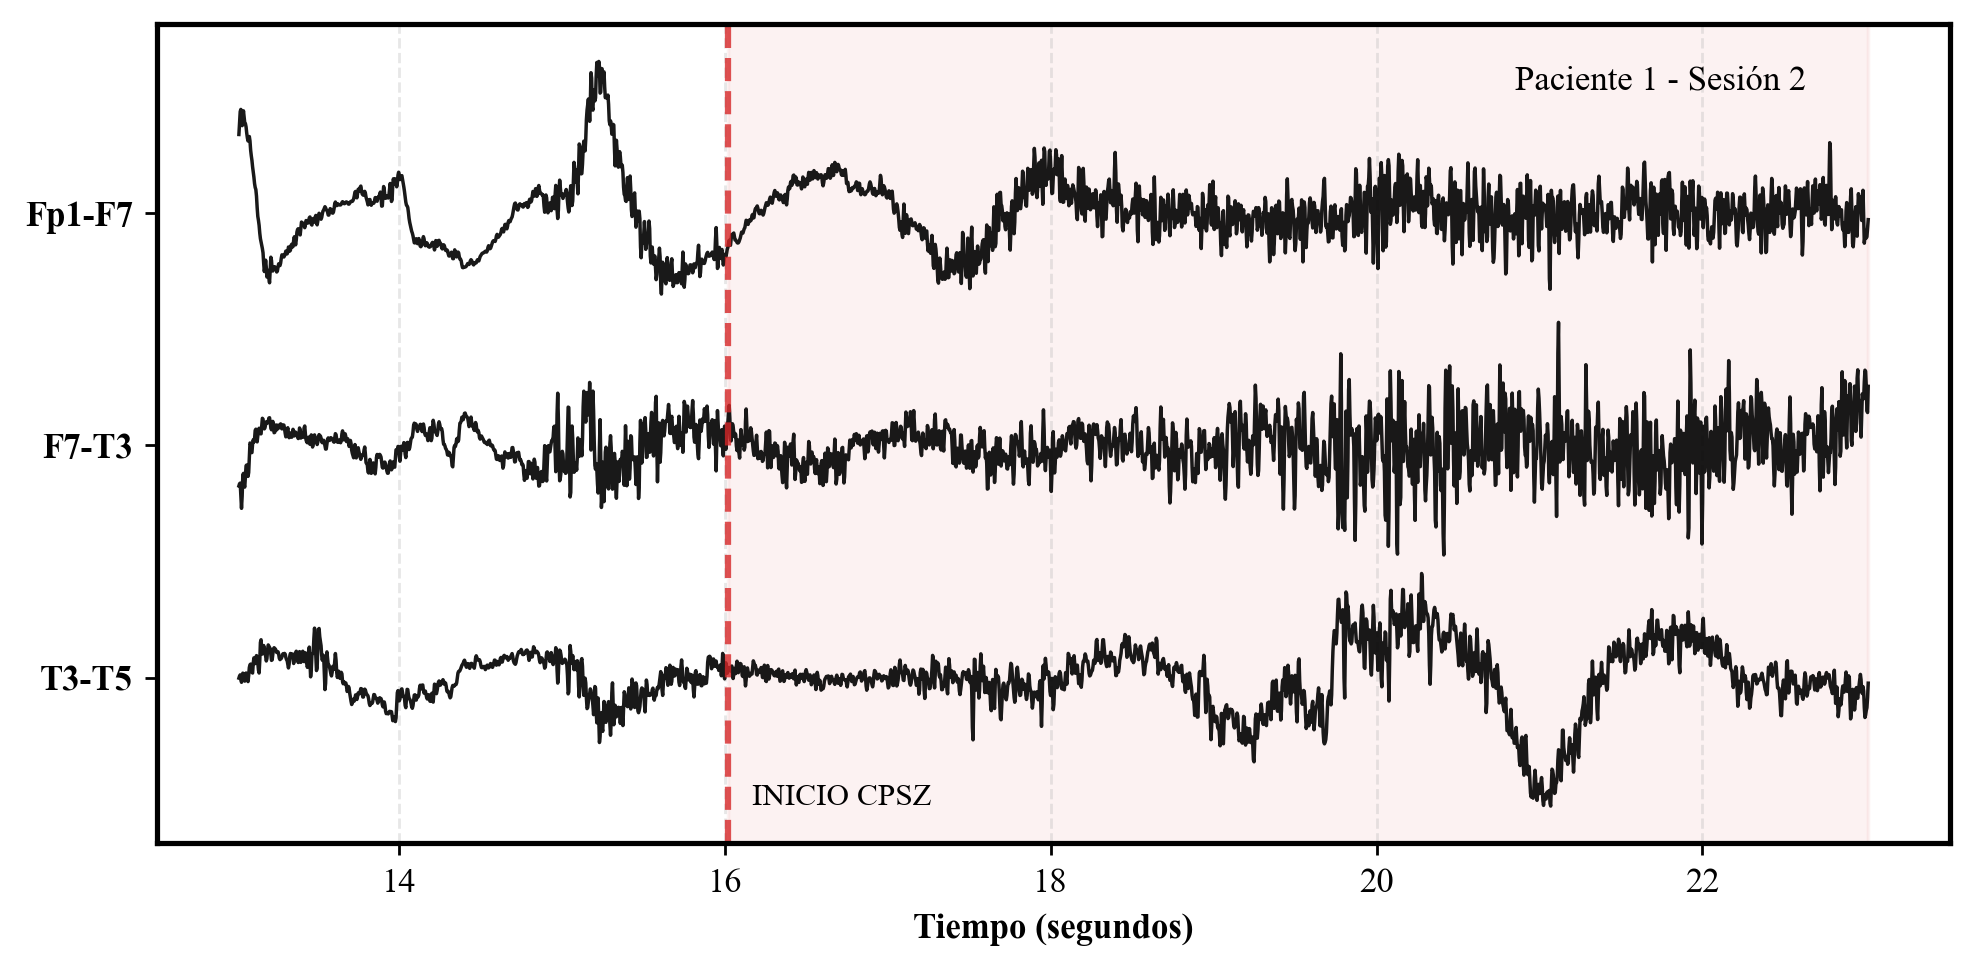

In [2]:
path_parquet = r"D:\TUSZ_project\TUSZ_DataLake\03_TUSZ_Clean\1\s002\t000.parquet"
path_csv = r"D:\TUSZ_project\TUSZ_DataLake\01_Raw_Consolidated\1\s002_2002\aaaaaaac_s002_t000.csv"
plot_seizure(path_parquet, path_csv)

# Arquitectura del Sistema: Decisiones de Diseño y Refinamiento del Corpus

Dada la heterogeneidad intrínseca del corpus TUSZ, el desarrollo de un sistema de clasificación robusto exige el establecimiento de lineamientos técnicos explícitos que garanticen la integridad y comparabilidad de las señales. Estas decisiones de diseño no representan simples filtros de limpieza, sino que constituyen la base arquitectónica sobre la cual opera el modelo predictivo. En esta sección, se discuten brevemente las definiciones adoptadas respecto a la selección y montaje de canales, la estandarización de las frecuencias de muestreo, los protocolos para el tratamiento de artefactos fisiológicos y la metodología de extracción de características. Cada una de estas elecciones conlleva implicaciones directas en la capacidad de generalización del sistema, buscando equilibrar la riqueza informativa de los registros clínicos con la estabilidad computacional necesaria para un monitoreo en tiempo real.

La primera decisión de diseño fundamental concierne al número de canales y la topografía de los registros a procesar. Como se evidenció en el análisis descriptivo previo, las sesiones del corpus TUSZ exhiben una variabilidad considerable tanto en el número de electrodos como en las configuraciones de montaje utilizadas durante más de 20 años de práctica clínica. Ante esta heterogeneidad, el sistema se ha decantado por la adopción estricta del Sistema Internacional 10-20, por ser el estándar de posicionamiento de electrodos más reconocido y validado a nivel global.

:::{admonition} Nota Metodológica: Sistema Internacional 10-20
:class: note

El Sistema Internacional 10-20 constituye el protocolo metodológico estandarizado para la colocación topográfica de electrodos en el cuero cabelludo durante los registros electroencefalográficos. Su fundamento radica en establecer coordenadas basadas en relaciones proporcionales, y no en medidas absolutas, utilizando puntos de referencia anatómicos craneales fijos (el nasion, el inion y los puntos preauriculares). La designación "10-20" indica que la separación entre electrodos adyacentes representa el 10% o el 20% de la longitud total de los ejes sagital y coronal de la cabeza (Jasper, 1958, como se cita en [Jurcak et al., 2007](https://doi.org/10.1016/j.neuroimage.2006.09.024)).

La adopción de este sistema de posicionamiento relativo en los registros del corpus TUSZ resulta de vital importancia para el modelado computacional. Al normalizar las distancias, se garantiza la coherencia espacial y la comparabilidad intersujeto de las topologías corticales, mitigando eficazmente el ruido estadístico derivado de la variabilidad biométrica natural en el tamaño y la forma de la cabeza de los distintos pacientes.
:::

Esta elección de diseño implica prescindir de aquellas sesiones que no integran la totalidad de los electrodos requeridos por dicho sistema. Si bien estas sesiones son numéricamente minoritarias, su exclusión representa un impacto significativo en el volumen de datos, alcanzando un 15.27% del tiempo total (aproximadamente 223.47 horas). A pesar de la magnitud de esta pérdida, se ha apostado por entrenar al sistema bajo condiciones de estandarización espacial rigurosa. Esta decisión busca eliminar el ruido derivado de la inconsistencia topográfica, garantizando que el predictor aprenda patrones electroencefalográficos basados en una geometría craneal coherente y comparable entre todos los sujetos de la muestra.


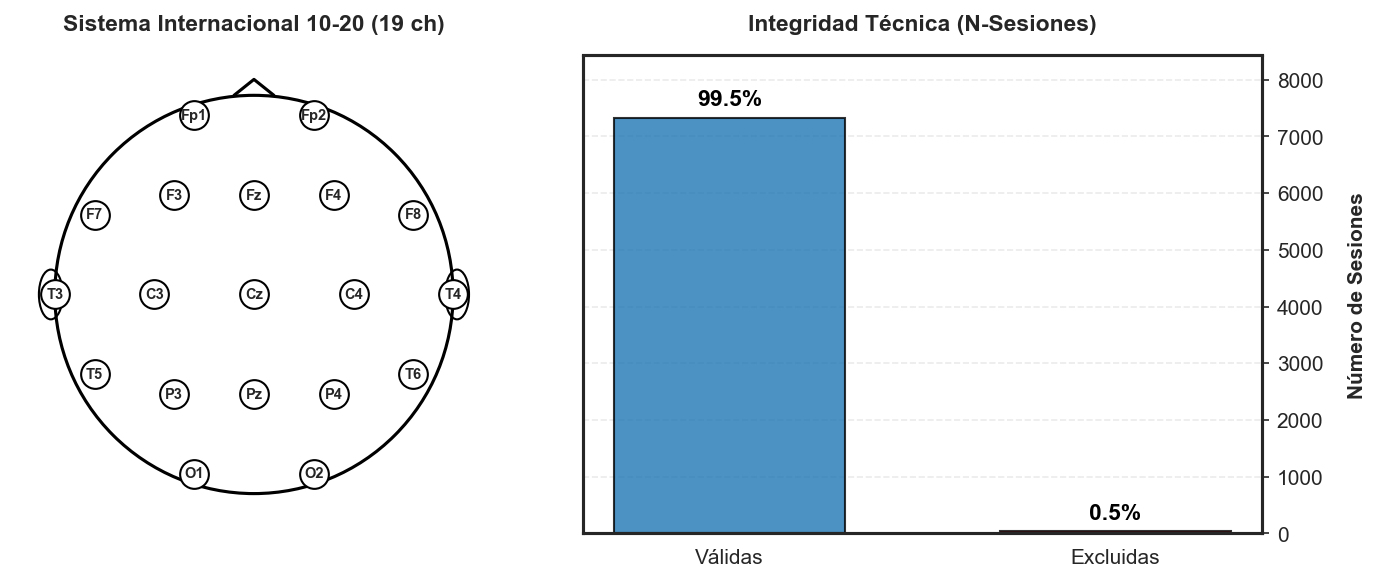

In [21]:
PATH_METADATA_SESSIONS = r"D:\TUSZ_project\TUSZ_DataLake\02_Metadata\metadata_sessions.parquet"
plot_integrity_1020(PATH_METADATA_SESSIONS)

La segunda decisión de diseño fundamental aborda la inconsistencia en los protocolos de referencia del corpus. El TUSZ es intrínsecamente heterogéneo al mezclar registros con Referencia Promediada (01_tcp_ar y 03_tcp_ar_a) y registros con Referencia en Orejas (02_tcp_le). Dado que cada protocolo establece un "cero" eléctrico distinto, los voltajes brutos no son comparables entre sesiones, lo que introduciría un sesgo técnico masivo en el modelo de Machine Learning.

Para resolver esta disparidad, se implementó una re-referenciación digital hacia un montaje bipolar. El principio de diferencia de potencial permite cancelar la referencia común, independientemente de su origen. Si consideramos dos electrodos adyacentes $i$ y $j$, sus potenciales medidos bajo distintas configuraciones se definen como:

* En configuración AR (01 y 03): $V_{i, AR} = S_i + Ref_{AR}$ y $V_{j, AR} = S_j + Ref_{AR}$

* En configuración LE (02): $V_{i, LE} = S_i + Ref_{LE}$ y $V_{j, LE} = S_j + Ref_{LE}$

Al aplicar la sustracción para obtener el montaje bipolar, calculamos:

$$V_{diff} = (S_i + Ref) - (S_j + Ref) = S_i - S_j$$

Como se observa en la ecuación, el término del potencial de referencia ($Ref$) se anula completamente. El resultado, $S_i - S_j$, representa la actividad cortical local pura y es matemáticamente idéntico sin importar el protocolo original. Esta propiedad es la que permite fusionar los tres grupos en un único Data Lake homogéneo, garantizando que el modelo aprenda patrones electroencefalográficos reales y no sesgos derivados del equipo de adquisición.

:::{admonition} Nota Metodológica: Montaje Bipolar
:class: note

Para mitigar la contaminación por ruido ambiental y los efectos de conducción de volumen, se implementó una re-referenciación digital hacia un montaje **Bipolar Longitudinal** (comúnmente denominado *"Double Banana"*). Desde una perspectiva de procesamiento de señales, este montaje actúa como un **filtro espacial de primer orden**. En lugar de utilizar una referencia común, la cual puede propagar artefactos globales a toda la red de sensores, el montaje bipolar calcula la diferencia de potencial entre electrodos adyacentes siguiendo la relación:

$$V_{diff}(t) = V_i(t) - V_j(t)$$

Donde $V_i$ y $V_j$ representan los potenciales medidos en electrodos contiguos sobre la corteza. Este procedimiento garantiza la **cancelación de señales en modo común** y acentúa los gradientes de voltaje locales asociados a la actividad ictal focal, permitiendo una interpretación neurofisiológica más precisa de las descargas paroxísticas.
:::

La tercera decisión de diseño fundamental se centra en la resolución temporal del sistema mediante la normalización de la frecuencia de muestreo ($f_s$). Debido a la naturaleza cronológica del corpus TUSZ, que abarca dos décadas de tecnología clínica, los registros presentan tasas de digitalización dispares que oscilan entre los 250 Hz y los 1000 Hz. Esta heterogeneidad imposibilita el entrenamiento de modelos de aprendizaje automático sobre ventanas de tiempo fijas, ya que el número de puntos por segmento variaría drásticamente entre sesiones.Para resolver esta inconsistencia, se ha procedido a un re-muestreo unificado de todas las señales a 250 Hz. Esta elección técnica satisface rigurosamente el Teorema de Nyquist-Shannon, estableciendo una frecuencia crítica de plegamiento (*folding frequency*) de:$$f_{Nyquist} = \frac{f_s}{2} = 125 \text{ Hz}$$Dicho margen de seguridad resulta óptimo para el análisis de componentes espectrales de hasta 80 Hz (correspondientes a la Banda Gamma), garantizando la captura de transitorios rápidos y actividad paroxística sin riesgo de distorsión por aliasing. Además de asegurar la integridad de la señal clínica relevante, esta decisión optimiza el costo computacional del pipeline, permitiendo que el modelo reciba vectores de entrada con una arquitectura temporal constante y homogénea.

Finalmente, la cuarta decisión de diseño se fundamenta en el uso de filtros digitales y la Transformada Wavelet Discreta (DWT) para lograr una extracción precisa de las bandas de frecuencia clínicas. De manera complementaria, se implementó un ventaneo diferencial durante la fase de entrenamiento como estrategia para mitigar el desbalance de clases; esta técnica aumenta la densidad de ejemplos de crisis, asegurando que el modelo capture los patrones patológicos críticos sin verse sesgado por la predominancia masiva de la actividad basal.

:::{admonition} Nota Metodológica: Transformada Wavelet Discreta (DWT) y Familia db4
:class: note

Para la transformación de las ventanas de 4.096 segundos en vectores de características discriminativos, se implementó una Transformada Wavelet Discreta (DWT) basada en el algoritmo de [Mallat](https://doi.org/10.1109/34.192463) (banco de filtros de espejo en cuadratura). A diferencia de la Transformada de Fourier (STFT), que emplea una base de funciones sinusoidales de duración infinita, la DWT utiliza funciones base localizadas tanto en tiempo como en frecuencia. Esta elección es crítica por tres razones fundamentales:

* **No Estacionariedad:** El EEG es una señal no estacionaria cuyas propiedades estadísticas varían en el tiempo. Mientras que Fourier asume periodicidad y promedia los eventos transitorios, la DWT es ideal para capturar paroxismos y cambios bruscos de voltaje.
* **Multirresolución:** Según el principio de incertidumbre, la DWT ofrece una resolución variable: ventanas estrechas para altas frecuencias y ventanas anchas para bajas frecuencias, optimizando el teselado del plano tiempo-frecuencia.
* **Semejanza Morfológica:** Las bases de Fourier no guardan similitud con la actividad ictal. En contraste, se seleccionó explícitamente la familia **Daubechies de cuarto orden (db4)** debido a que su morfología presenta una alta correlación temporal con los complejos punta-onda y las descargas rítmicas del EEG, permitiendo una representación más rala (*sparse*).

Matemáticamente, la DWT descompone una señal discreta $x(n)$ proyectándola sobre una base de funciones wavelet $\psi_{j,k}(n)$ y funciones de escala $\phi_{j,k}(n)$, definidas mediante traslaciones y dilataciones diádicas:

$$\psi_{j,k}(n) = 2^{-j/2}\psi(2^{-j}n - k)$$

Donde $j$ representa el nivel de descomposición (escala) y $k$ el desplazamiento temporal. Así, la señal original puede representarse mediante la combinación lineal de sus coeficientes de aproximación (A) y detalle (D): 

$$x(n) = \sum_{k} c_{j_0,k}\phi_{j_0,k}(n) + \sum_{j=j_0}^{J} \sum_{k} d_{j,k}\psi_{j,k}(n)$$
:::

La implementación de la DWT permitió identificar dos registros cuyos patrones no correspondían a actividad electroencefalográfica (EEG) real, tratándose presumiblemente de errores técnicos de adquisición o fallos en el equipo. Dada su naturaleza de datos espurios, ambos registros fueron excluidos del sistema para evitar la introducción de ruido no biológico en el modelo de entrenamiento.


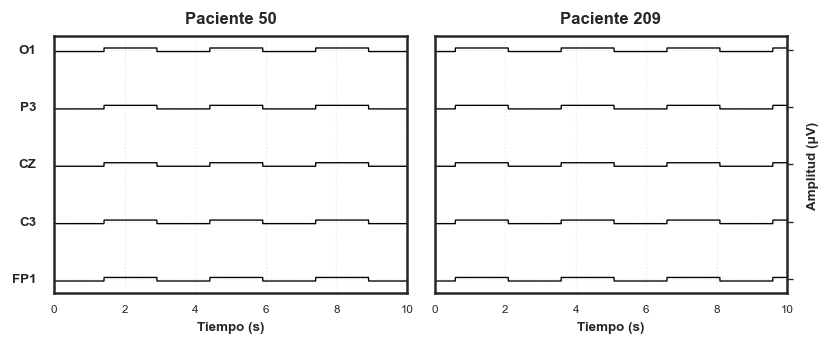

In [36]:
RAW_ROOT = r"D:\TUSZ_project\TUSZ_DataLake"
plot_exclusion(RAW_ROOT)

Para concluir esta sección, se presentan de manera sintetizada los efectos de la estrategia de ventaneo diferencial sobre la muestra de entrenamiento. Al implementar un desplazamiento (step) de 1 segundo en los periodos de crisis —en contraste con la ventana nominal de 4.096 segundos—, se generó un efecto de redundancia controlada que permitió incrementar el peso relativo de las clases Focal y Generalizada, reduciendo significativamente la dominancia de la actividad basal en el conjunto final. La sigueinte figura resume los resultados de este proceso:


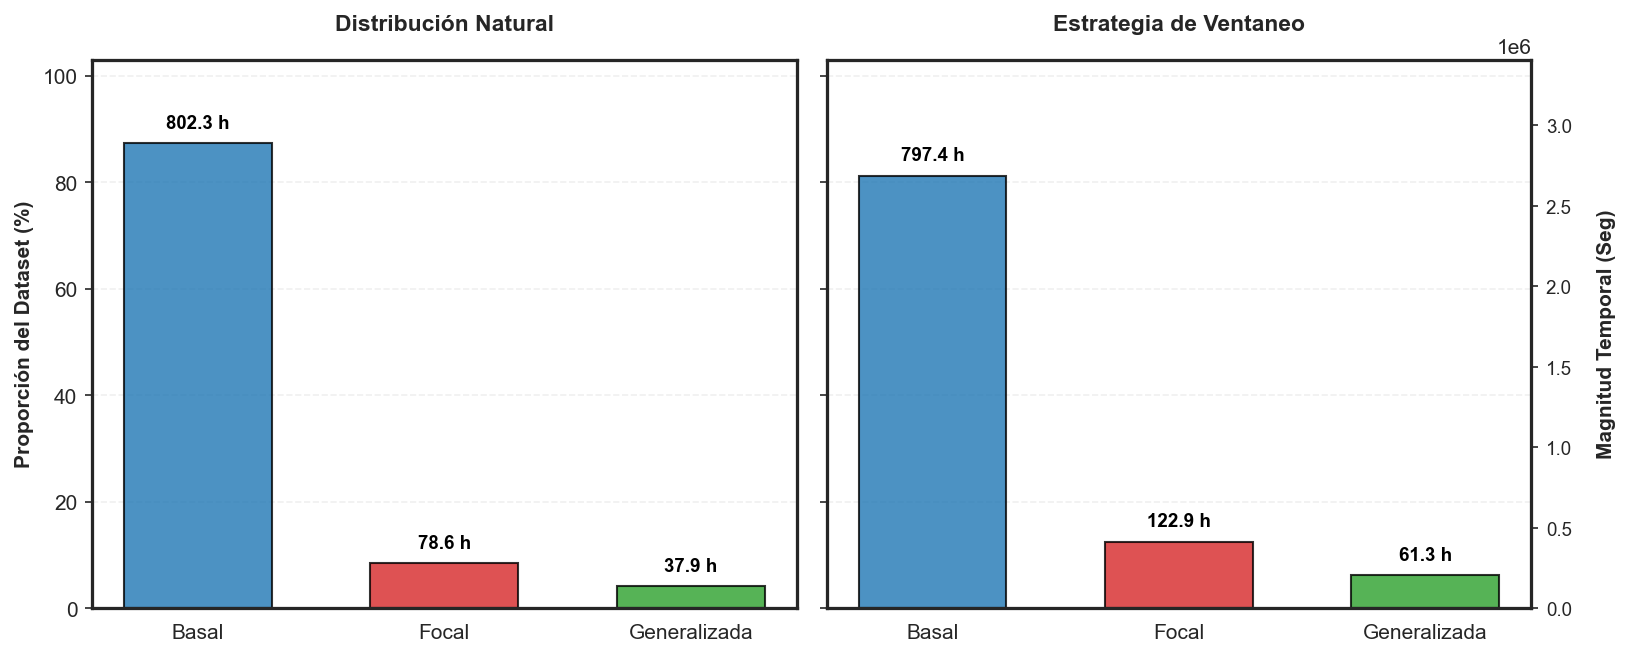

In [43]:
CSV_PATH = r"D:\TUSZ_project\TUSZ_DataLake\01_Raw_Consolidated"
PARQUET_PATH = r"D:\TUSZ_project\TUSZ_DataLake\04_TUSZ_Features_ML\version=v2_augmented_labels"
df_original, df_final = get_train_audit(CSV_PATH, PARQUET_PATH, PATH_META_PATIENTS)
plot_train_comparison(df_original, df_final)

Como se observa en la comparativa, mientras que la distribución natural relega las crisis a una proporción marginal, el aumento por solapamiento elevó la prevalencia temporal de las macroclases ictales. Específicamente, la clase Focal aumentó de 78.6 h a 122.9 h (representando un 156.36% de su volumen original), mientras que la clase Generalizada pasó de 37.9 h a 61.3 h (alcanzando el 161.74% de su magnitud inicial). Cabe notar que, aunque la clase Basal disminuyó su proporción relativa, su volumen de tiempo absoluto se mantuvo casi constante (99.38% respecto al original).

Si bien el diseño teórico del solapamiento apuntaba a cuadruplicar la cantidad de muestras en las clases ictales, la variabilidad en la duración real de los eventos y su diversidad morfológica impiden un incremento uniforme en todas las categorías. En cualquier caso, se considera que la estrategia fue exitosa al robustecer el dataset, estableciendo una base sólida que será complementada con estrategias adicionales de equilibrado de pesos durante la fase de entrenamiento de los modelos predictivos.

# Caracterización Neurofisiológica de las Macroclases

Para garantizar la integridad del modelo de clasificación y evitar el sesgo de selección o la fuga de información (*data leakage*), el análisis descriptivo y la validación estadística se realizaron exclusivamente sobre el conjunto de entrenamiento. Este conjunto comprende los datos de 471 pacientes, manteniendo el set de prueba (*holdout set*) completamente aislado para la evaluación final del rendimiento.

Dado el desbalance inherente en la base de datos TUSZ y con el objetivo de capturar la variabilidad neurofisiológica sin sobre-representar a sujetos específicos, se implementó un submuestreo probabilístico de las sesiones. Este procedimiento se realizó de forma estratificada por paciente y macroclase de crisis, asegurando que las distribuciones presentadas en este análisis reflejen fielmente las firmas electrofisologicas de los eventos ictales y basales, independientemente de la duración total de los registros de cada individuo.

In [4]:
PATH_SESSION = r"D:\TUSZ_project\TUSZ_DataLake\04_TUSZ_Features_ML"
df_sample = create_sample(PATH_SESSION, PATH_META_PATIENTS)
cols_a_excluir = ['partition_id', 'win_start_sec', 'label', 'original_class', 'patient_id']
df_re = df_sample.copy()
df_3D = df_sample.copy()
df_sample = df_re.drop(columns=[c for c in cols_a_excluir if c in df_sample.columns])

## Selección de Atributos: Relevancia y Redundancia

Dada la alta dimensionalidad del espacio de características original ($d = 1.143$), realizar un análisis individual de cada descriptor resulta computacionalmente inviable y estadísticamente propenso al ruido. Por lo tanto, se implementó un protocolo de selección de características basado en la Teoría de la Información, priorizando aquellas variables que maximizan la separación de las macroclases clínicas mientras minimizan la redundancia entre sí.

El *coeficiente de información mutua* (MI por sus siglas en ingles) cuantifica la reducción de la incertidumbre sobre la variable objetivo $Y$ (clase de crisis) tras observar una característica $X$. A diferencia de la correlación lineal, la MI captura dependencias no lineales complejas, lo cual es crítico en señales biomédicas como el EEG. Matemáticamente, se define como:$$MI(X; Y) = H(X) + H(Y) - H(X, Y)$$Donde $H(\cdot)$ representa la Entropía de Shannon, definida como la medida de incertidumbre de una variable aleatoria.

Para refinar la selección, se aplicó el algoritmo *Minimum Redundancy Maximum Relevance* (mRMR). Este método no solo busca variables con alta MI respecto a la clase objetivo, sino que penaliza aquellas que presentan una alta dependencia entre sí. El ranking se determina mediante la optimización del cociente o la diferencia entre estos dos componentes:$$f_{mRMR}(X_i) = \text{max} \left[ MI(X_i; Y) - \frac{1}{|S|} \sum_{X_j \in S} MI(X_i; X_j) \right]$$Donde:

* $S$ es el conjunto de características ya seleccionadas.
  
* $MI(X_i; Y)$ es la relevancia de la característica candidata respecto al objetivo.

* $\frac{1}{|S|} \sum MI(X_i; X_j)$ es la redundancia media de la candidata con las variables ya elegidas.


:::{admonition} Nota Metodológica
:class: note

Es importante precisar que los rankings de **Información Mutua** y **mRMR** presentados en esta sección no constituyen una restricción *a priori* para los modelos de aprendizaje automático. 

En la fase de entrenamiento, la totalidad de los atributos son considerados por los algoritmos, permitiendo una **selección de características posterior** basada en la capacidad predictiva real sobre los datos. No obstante, este análisis de relevancia permitió acotar el Análisis Exploratorio de Datos (EDA) a las 15 variables con mayor sustento teórico e informacional, facilitando una interpretación neurofisiológica profunda de los descriptores con mayor impacto en la discriminación de las crisis.
:::

In [5]:
import pandas as pd
from IPython.display import HTML, display

ranking = get_top_features_ranking(df_sample, top_k=15)
ranking['mRMR Rank'] = list(range(1, 16))
cols = ['mRMR Rank'] + [c for c in ranking.columns if c != 'mRMR Rank']
ranking = ranking[cols]
df_ranking = pd.DataFrame(ranking)
n_vars = len(df_ranking)
mid_idx = (n_vars + 1) // 2
df_left = df_ranking.iloc[:mid_idx].reset_index(drop=True)
df_right = df_ranking.iloc[mid_idx:].reset_index(drop=True)

if len(df_right) < len(df_left):
    for i in range(len(df_right), len(df_left)):
        df_right.loc[i] = [None, "", None, None]

df_right.columns = ['Rank (cont.)', 'Feature (cont.)', 'Mutual Info (cont.)', 'IQR (cont.)']
dual_ranking = pd.concat([df_left, df_right], axis=1)

format_map = {
    "Mutual Info": "{:.4f}", "IQR": "{:.4f}",
    "Mutual Info (cont.)": lambda x: "{:.4f}".format(x) if pd.notnull(x) else "",
    "IQR (cont.)": lambda x: "{:.4f}".format(x) if pd.notnull(x) else "",
    "Rank": lambda x: "{:.0f}".format(x) if pd.notnull(x) else "",
    "Rank (cont.)": lambda x: "{:.0f}".format(x) if pd.notnull(x) else ""
}

styled_dual = dual_ranking.style.format(format_map).hide(axis='index')
styled_dual = styled_dual.set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), 
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), 
                                  ('color', 'black'), ('font-weight', 'bold'), 
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), 
                                  ('padding', '6px 12px')]}
])

styled_dual = styled_dual.set_properties(subset=['Feature', 'Feature (cont.)'], **{'text-align': 'left'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dual.to_html() + "</div>"))

mRMR Rank,Feature,Mutual Info,IQR,Rank (cont.),Feature (cont.),Mutual Info (cont.),IQR (cont.)
1,Cz-Pz_D2_ent,0.1858,0.3965,9,P4-O2_D1_ent,0.1702,0.4185
2,P4-O2_D3_rms,0.1455,0.3647,10,F3-C3_D5_ll,0.1307,0.9173
3,T5-O1_D5_teo,0.0590,2.8432,11,Cz-Pz_D1_ent,0.1558,0.3973
4,C4-P4_A5_mean,0.0209,0.8787,12,Fp1-F7_D5_ll,0.1418,0.9401
5,Fp1-F3_D5_ll,0.1371,1.0366,13,F8-T4_D2_ll,0.1501,0.5277
6,P4-O2_D2_ent,0.1875,0.4606,14,P3-O1_D1_ent,0.1452,0.4113
7,T5-O1_D2_ll,0.1462,0.3032,15,Fp2-F8_D5_ll,0.1096,0.9227
8,P3-O1_A5_ll,0.1692,1.2024,,,,


El ranking mRMR revela una selección sinérgica donde la Entropía en bandas rápidas (Gamma/Beta) en regiones de integración central (Cz-Pz) y posterior (P4-O2) actúa como el principal biomarcador de la hipersincronía ictal. Este hallazgo se complementa con la inclusión de métricas de complejidad morfológica como el Line Length en bandas lentas (Theta/Delta) en áreas prefrontales (Fp1-F3). Esta combinación de componentes rápidos y lentos concuerda con la literatura científica reciente, la cual señala que las bandas de baja frecuencia no son meros artefactos de fondo, sino elementos que se integran cada vez más a los sistemas de predicción de crisis al capturar la neuromodulación y la propagación de la actividad epiléptica a larga escala.

## Caracterización Morfológica de Atributos

Dado que las distribuciones de los atributos extraídos mediante la Transformada Wavelet Discreta (DWT) no asumen necesariamente una morfología normal —presentando frecuentemente sesgos y variabilidad extrema en segmentos críticos—, se empleó la prueba no paramétrica de Kruskal-Wallis para evaluar la existencia de diferencias estadísticamente significativas entre las macroclases (Basal, Focal y Generalizada). La siguiente tabla muestra los resultados de dichas pruebas junto a la mediana y el rango intercuartil por grupos para facilitar la comparación:

:::{admonition} Nota Metodológica
:class: note

Es imperativo señalar que las distribuciones de los atributos presentan, en general, una naturaleza no normal con marcadas diferencias en su morfología y dispersión entre los grupos. Dado el propósito de este estudio, no se profundiza en un análisis exhaustivo de valores atípicos o propiedades distributivas específicas; en su lugar, se emplea el **test de Kruskal-Wallis** como un medio para evaluar las **diferencias estocásticas** entre las poblaciones. 

Bajo escenarios donde no se cumple el supuesto de igualdad de varianzas, la prueba de Kruskal-Wallis —si bien no evalúa estrictamente la localización (mediana)— mantiene su validez para identificar discrepancias en la estructura distributiva y morfológica de los datos ([Conover, 1999](https://www.wiley.com/en-us/Practical+Nonparametric+Statistics%2C+3rd+Edition-p-9780471160687)).
:::

In [5]:
import pandas as pd
from IPython.display import HTML, display

ranking_features = ranking["Feature"].tolist()
tabla_stats = run_kruskal(df_sample, ranking_features)

dicc_nombres = {
    'Background': 'Basal', 'Focal': 'Focal', 'Generalized': 'Generalizada',
    'background': 'Basal', 'focal': 'Focal', 'generalized': 'Generalizada'
}
tabla_stats = tabla_stats.rename(columns=dicc_nombres)

if 'Feature' in tabla_stats.columns:
    tabla_stats = tabla_stats.drop(columns=['Feature'])
elif tabla_stats.index.name == 'Feature' or 'Feature' in str(tabla_stats.index.name):
    tabla_stats.index.name = None

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict = {
    "H-Statistic": lambda x: smart_format(x, "{:.2f}"),
    "p-value": lambda x: smart_format(x, "{:.2e}"),
    "Basal": lambda x: smart_format(x, "{:.4f}"),
    "Focal": lambda x: smart_format(x, "{:.4f}"),
    "Generalizada": lambda x: smart_format(x, "{:.4f}")
}

styled_stats = tabla_stats.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), 
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), 
                                  ('color', 'black'), ('font-weight', 'bold'), 
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), 
                                  ('padding', '10px')]}
])

styled_stats = styled_stats.format(format_dict)
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_stats.to_html() + "</div>"))

Característica,Basal,Focal,Generalizada,Estadístico H,ε²,Magnitud del Efecto
Cz-Pz_D2_ent,1.91 (0.19),1.82 (0.22),1.48 (0.70),1064.12***,0.24,Moderado
P4-O2_D3_rms,0.50 (0.35),0.61 (0.21),0.62 (0.76),182.46***,0.04,Pequeño
T5-O1_D5_teo,2.28 (2.48),3.85 (3.45),2.53 (2.25),395.08***,0.09,Moderado
C4-P4_A5_mean,0.06 (0.81),0.30 (0.92),0.03 (0.84),136.05***,0.03,Pequeño
Fp1-F3_D5_ll,1.44 (0.89),1.54 (0.67),2.30 (1.16),978.23***,0.22,Moderado
P4-O2_D2_ent,1.89 (0.23),1.81 (0.26),1.40 (0.59),1063.00***,0.24,Moderado
T5-O1_D2_ll,0.31 (0.28),0.23 (0.09),0.43 (0.55),388.88***,0.09,Moderado
P3-O1_A5_ll,2.55 (0.99),2.72 (0.71),3.68 (1.32),846.30***,0.19,Moderado
P4-O2_D1_ent,1.84 (0.23),1.80 (0.20),1.42 (0.56),1084.80***,0.24,Moderado
F3-C3_D5_ll,1.52 (0.81),1.87 (0.71),2.31 (0.93),888.99***,0.20,Moderado


El análisis de la prueba de Kruskal-Wallis revela que las diferencias entre las macroclases van más allá de una simple métrica de probabilidad. Al observar los estadísticos $H$ y la magnitud del efecto ($\epsilon^2$), se evidencia que las disparidades morfológicas son el factor determinante; las distribuciones de los grupos no solo se desplazan, sino que cambian su estructura. Por ejemplo, en las métricas de Entropía (D1, D2) y Line Length (D5), las marcadas variaciones en la mediana y el rango intercuartil sugieren que cada grupo clínico habita un espacio estocástico distinto. Estas diferencias morfológicas —visibles en la asimetría y dispersión de los datos— confirman que, a pesar de la alta variabilidad intrínseca del EEG, existen firmas características para el estado Basal, Focal y Generalizado que los modelos de aprensizaje automatico podrian explotar para su discriminación, independientemente de la redundancia en los canales analizados.

Tras confirmar la existencia de diferencias globales, el análisis se centró en cuantificar la magnitud de dichas disparidades mediante multiples de rangos con signo de Mann-Whitney y el cálculo del tamaño del efecto (r de Rosenthal). A diferencia de la significancia estadística convencional, el tamaño del efecto permite evaluar la relevancia clínica y práctica de cada descriptor, identificando qué variables ofrecen una separación física real en el espacio de características. A continuación, se presentan los resultados para las seis características de mayor relevancia según el ranking mRMR, donde valores elevados del estadístico de efecto confirman que la discriminación entre los estados basal, focal y generalizado es robusta y no producto del ruido estocástico o del gran volumen de datos del corpus.

:::{admonition} Nota Metodológica: Tamaño del Efecto (r de Rosenthal) y Criterios de Interpretación
:class: note

En la evaluación de contrastes mediante la prueba no paramétrica de Mann-Whitney, la dependencia exclusiva del valor $p$ resulta analíticamente insuficiente. En corpus de alta densidad de datos, incluso diferencias minúsculas derivadas del ruido estocástico pueden alcanzar una aparente significancia estadística debido al volumen muestral. Para mitigar este sesgo, se calculó el tamaño del efecto conocido como la **r de Rosenthal**. Esta métrica cuantifica la magnitud real y direccional de la separación entre las distribuciones a partir del estadístico estandarizado $Z$ de la prueba y el tamaño total de la muestra $N$:

$$
r = \frac{Z}{\sqrt{N}}
$$

Siguiendo los estándares de interpretación consolidados en la literatura estadística propuestos originalmente por [Cohen (1988)](https://doi.org/10.4324/9780203771587), la magnitud del estadístico $|r|$ se evalúa bajo los siguientes umbrales heurísticos:

* **Efecto Pequeño** ($0.10 \leq |r| < 0.30$): Indica una separación débil, donde el solapamiento entre las distribuciones es sustancial.
* **Efecto Mediano** ($0.30 \leq |r| < 0.50$): Refleja una separación moderada pero consistente, aportando información útil para el modelado.
* **Efecto Grande** ($|r| \geq 0.50$): Señala una disparidad estructural profunda y altamente discriminatoria entre las macroclases.

Priorizar estos umbrales asegura que los atributos analizados no solo difieran estadísticamente, sino que posean una genuina y sustancial capacidad predictiva para el reconocimiento de patrones ictales.
:::

La inspección de las densidades de probabilidad revela contrastes morfológicos significativos que validan la capacidad discriminatoria de estos descriptores. En el caso de la Entropía (Banda Gamma, Cz-Pz), se observa una clara divergencia en la forma de las distribuciones: mientras que el estado basal y las crisis focales se concentran en un pico agudo hacia valores altos, la macroclase generalizada exhibe una distribución bimodal con un desplazamiento notable hacia la izquierda, indicando una alteración estructural en la complejidad de la señal. Por otro lado, la Amplitud RMS (Banda Beta, P4-O2) destaca por la expansión de su base en las clases ictales; mientras el estado basal presenta una distribución estrecha y centrada, las crisis focales muestran un apuntamiento desplazado hacia valores superiores y las generalizadas desarrollan una "cola larga" de alta variabilidad. Este comportamiento diferencial en el ancho de banda y la posición de los núcleos de densidad confirma que, aunque existe un solapamiento parcial, las fronteras de probabilidad son lo suficientemente distintas para permitir que un modelo no lineal identifique patrones únicos en la firma de cada macroclase.


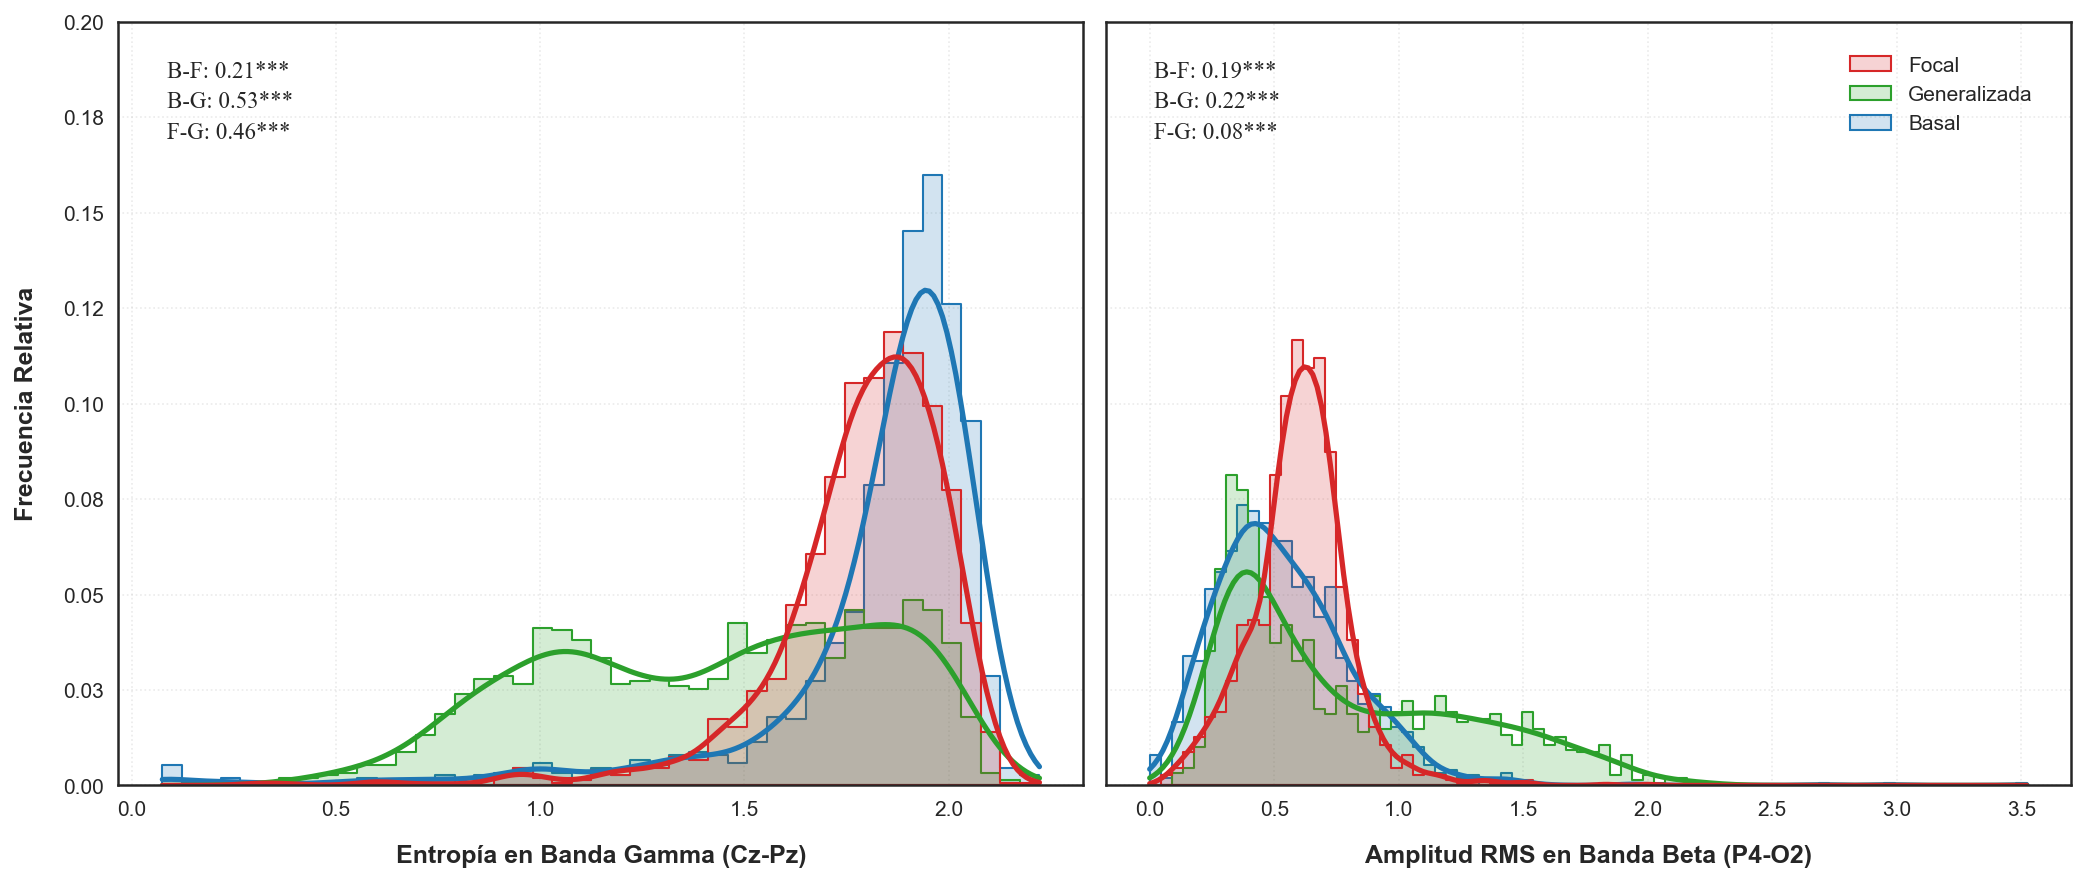

In [45]:
plot_kde(
    df_sample, 
    'Cz-Pz_D2_ent', 
    'P4-O2_D3_rms', 
    xlabel1="Entropía en Banda Gamma (Cz-Pz)", 
    xlabel2="Amplitud RMS en Banda Beta (P4-O2)", 
    ylabel="Frecuencia Relativa",
    ylim=0.20
)

La inspección de las densidades para este conjunto de descriptores revela una discriminación más sutil pero estadísticamente relevante, donde el tamaño del efecto actúa como el principal indicador de separabilidad. En la Energía Teager (Banda Delta, T5-O1), se observa una morfología de *cola pesada* extremadamente marcada en las crisis focales y generalizadas; aunque el contraste entre ambas es moderado ($r = 0.28$), la separación respecto al estado basal es significativa, especialmente para las crisis focales ($r = 0.34$), indicando que este operador de energía no lineal captura transiciones bruscas en la actividad delta que son inexistentes en el reposo. Por el contrario, el Promedio de Amplitud (Banda Delta, C4-P4) exhibe las distribuciones más solapadas del conjunto, lo cual se refleja en tamaños de efecto pequeños. El contraste Basal-Generalizada es prácticamente nulo ($r = 0.02$), evidenciando una identidad morfológica casi idéntica en términos de amplitud media para esta banda; no obstante, las crisis focales logran una ligera distinción respecto al fondo ($r = 0.17$) y a las generalizadas ($r = 0.19$), mostrando un leve ensanchamiento en la base de la densidad que sugiere una mayor presencia de fluctuaciones de voltaje en eventos localizados.


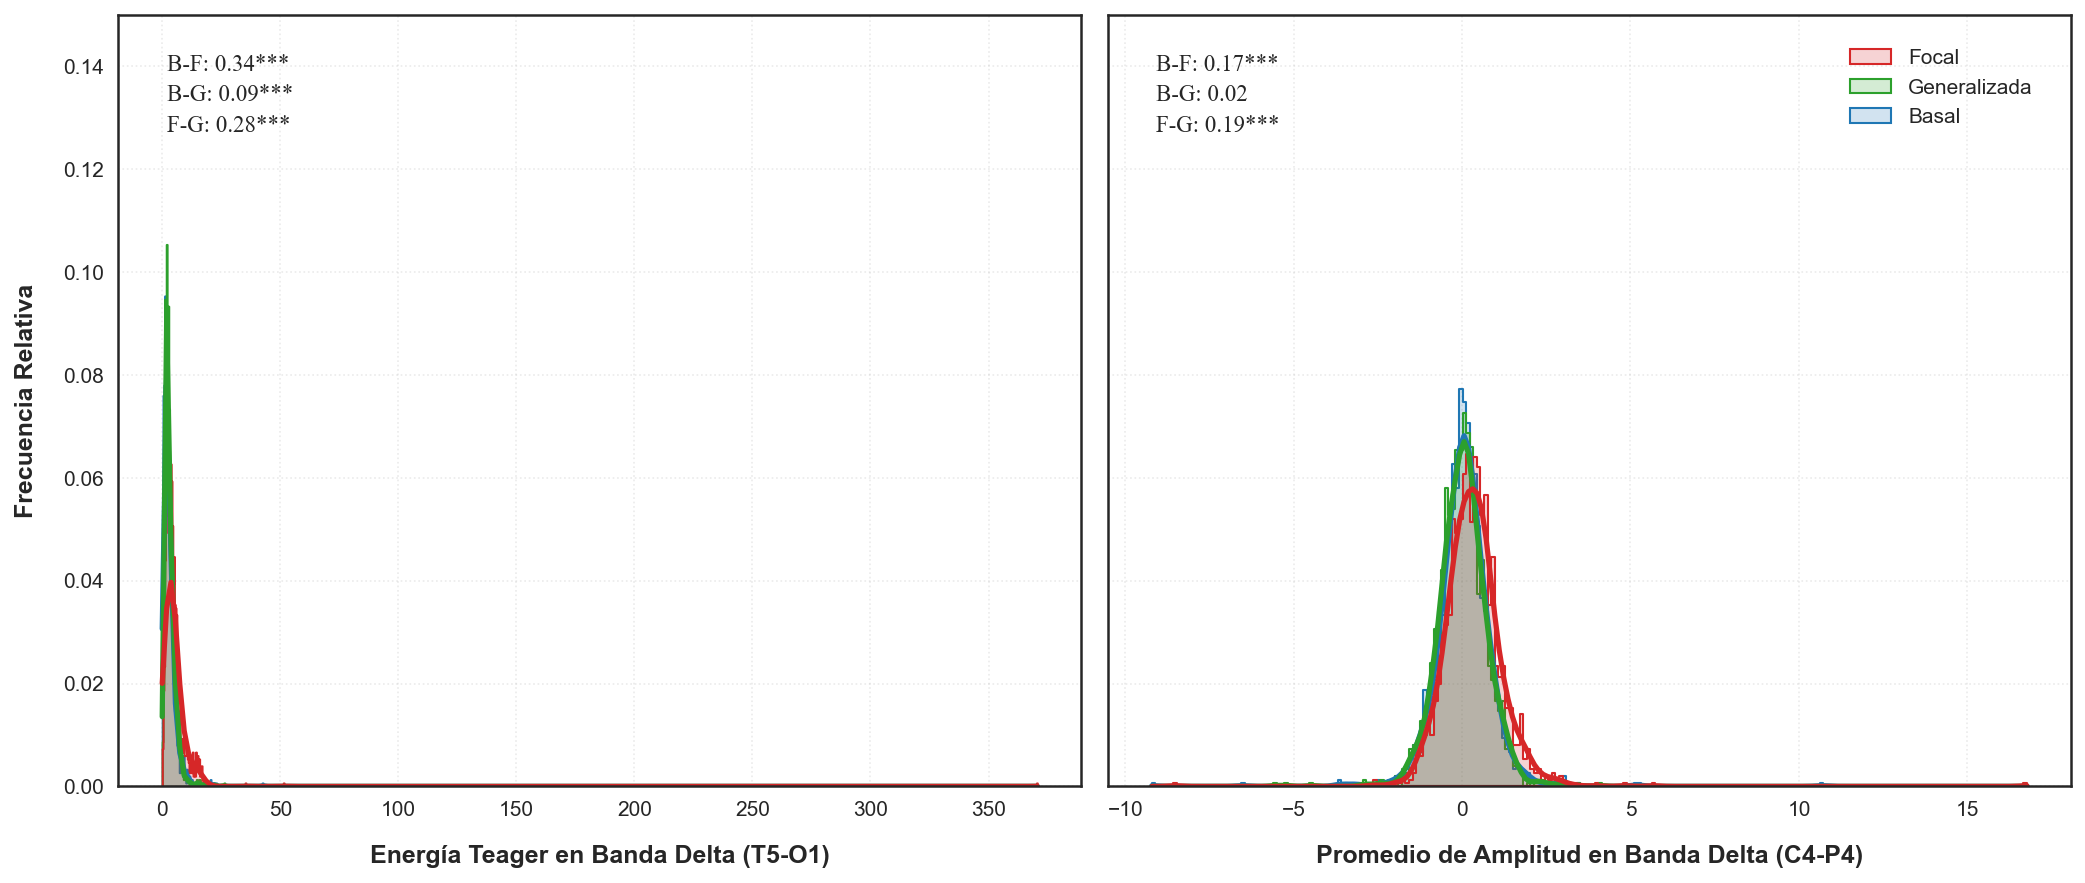

In [53]:
plot_kde(
    df_sample, 
    'T5-O1_D5_teo', 
    'C4-P4_A5_mean', 
    xlabel1="Energía Teager en Banda Delta (T5-O1)", 
    xlabel2="Promedio de Amplitud en Banda Delta (C4-P4)", 
    ylabel="Frecuencia Relativa",
    ylim=0.15
)

Finalemente, las densidades para este último conjunto de descriptores confirma una diferenciación estructural profunda, especialmente en los contrastes que involucran la macroclase generalizada. En el caso del Line Length (Banda Theta, Fp1-F3), se observa un desplazamiento masivo de la distribución generalizada hacia la derecha en comparación con el estado basal ($r = 0.50$) y focal ($r = 0.48$), lo que se traduce en un tamaño de efecto grande; esto indica que la mayor sinuosidad y amplitud rítmica de las crisis generalizadas en regiones frontales permite una separación casi lineal de su densidad. Por su parte, la Entropía (Banda Gamma, P4-O2) replica el comportamiento de "enfriamiento" observado en otras localizaciones, donde las crisis generalizadas muestran una distribución bimodal y achatada que se aleja drásticamente de los picos agudos del estado basal ($r = 0.53$) y focal ($r = 0.48$). Estos resultados subrayan que, mientras la actividad basal y focal conservan una firma de desorden similar en frecuencias altas, la transición hacia una crisis generalizada impone una organización rítmica que altera de forma drástica y medible la entropía y la longitud de línea de la señal.


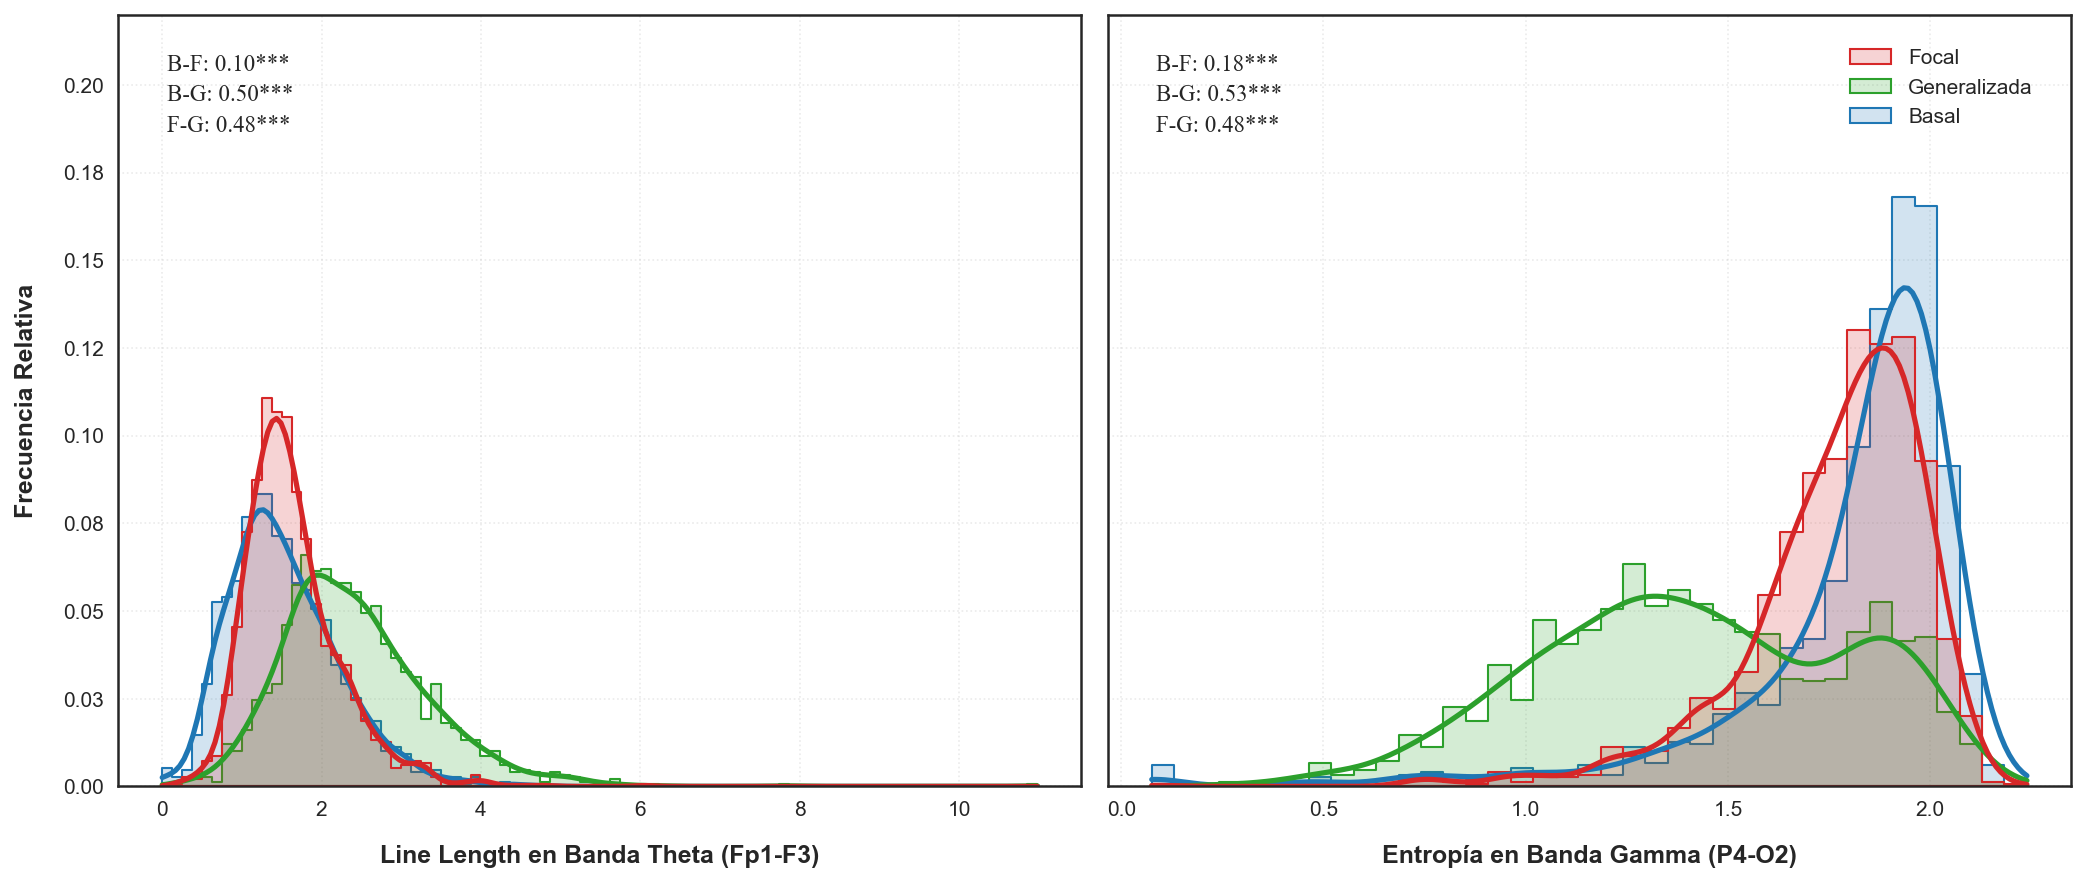

In [51]:
plot_kde(
    df_sample, 
    'Fp1-F3_D5_ll', 
    'P4-O2_D2_ent', 
    xlabel1="Line Length en Banda Theta (Fp1-F3)", 
    xlabel2="Entropía en Banda Gamma (P4-O2)", 
    ylabel="Frecuencia Relativa",
    ylim=0.22
)

En conjunto, el análisis de densidades revela un patrón consistente: la macroclase de las crisis generalizadas exhibe las morfologías más diferenciadas y los mayores tamaños de efecto frente al estado basal. La única excepción es la amplitud promedio en la banda Delta (C4-P4_A5_mean), donde el solapamiento con la actividad de fondo es casi total. Clínicamente, esto responde a que la actividad Delta de alta amplitud no es exclusiva de los eventos paroxísticos, presentándose también durante estados de menor alerta (somnolencia, sueño) o como un enlentecimiento interictal difuso muy común en pacientes epilépticos. En consecuencia, la magnitud del voltaje en bajas frecuencias carece de especificidad para delinear fronteras ictales, esto puede llegar a sugerir que la firma discriminatoria de las crisis generalizadas radica en la disrupción de la complejidad de la señal capturada por descriptores no lineales en frecuencias más altas.

## Topografía Cerebral de Biomarcadores

Una vez confirmada la existencia de diferencias estocásticas significativas, este apartado busca aterrizar dichos hallazgos en la dimensión espacial del cuero cabelludo. Para obtener una visión representativa de la dinámica cerebral entre las macroclases, el análisis se centra en tres variables críticas que encabezan tanto el ranking de relevancia mRMR como los mayores tamaños del efecto: Cz-Pz_D2_ent, T5-O1_D5_teo y Fp1-F3_D5_ll.

Estas variables no han sido seleccionadas al azar; representan una tríada de descriptores que capturan facetas distintas del fenómeno epiléptico: la pérdida de complejidad organizativa en la banda Gamma (D2) en el vértice central, junto al incremento de energía transitoria y la deformación morfológica en el ritmo Theta (D5) en las regiones temporo-occipitales y prefrontales, respectivamente. Es relevante notar que, si bien la sincronía se manifiesta en frecuencias rápidas, la mayoría de los atributos seleccionados corresponden a la banda D5. Esto es neurofisiológicamente coherente con la literatura actual: el ritmo Theta es un componente fundamental para la detección de crisis, ya que captura la lentificación rítmica y la descarga paroxística característica de los eventos epileptiformes, integrándose como un pilar en la predicción de la actividad ictal.

:::{admonition} Nota Metodológica
:class: note

Aunque el análisis previo se centró en variables de canales específicos según el ranking mRMR, para la generación de los **mapas topográficos (topomaps)** se evalúa el comportamiento del descriptor en la totalidad de la corteza. Se utiliza el **sistema internacional 10-20** como referencia espacial, aprovechando el montaje de **doble banana** (bipolar longitudinal) para resaltar los gradientes de cambio locales y la propagación de la actividad. 

Dada la naturaleza no normal y la presencia de sesgos en las distribuciones morfológicas de los atributos, se emplea la **mediana** como medida de tendencia central robusta para resumir la activación de cada canal por macroclase, garantizando una representación fiel de la dinámica predominante en el grupo de entrenamiento.
:::

### Entropía Wavelet (Banda D2 - Gamma)

La Entropía Wavelet cuantifica la complejidad o "riqueza informacional" de la señal, evaluando qué tan heterogénea es la distribución de sus componentes. A diferencia del cálculo tradicional sobre la serie temporal cruda, este enfoque utiliza la Transformada Wavelet Discreta (DWT) para analizar la incertidumbre en niveles de resolución específicos. Matemáticamente, si definimos $C_{j,k}$ como los coeficientes en el nivel de detalle $j$ (donde $j=2$ corresponde a nuestra banda Gamma), la probabilidad de distribución de energía relativa se expresa como $p_k = |C_{j,k}|^2 / \sum |C_{j,k}|^2$. A partir de esta distribución, la Entropía de Shannon se calcula como:$$H(j) = -\sum_{k=1}^{N} p_k \log_2(p_k)$$En este contexto, la banda Gamma (D2) actúa como un reflejo directo de la dinámica de las redes neuronales locales y el procesamiento de información de alta velocidad. Una entropía elevada en esta banda indica un estado basal saludable caracterizado por una actividad multiespectral y desincronizada. Por el contrario, el descenso de este valor durante un evento ictal revela un fenómeno de hipersincronía patológica, donde la señal pierde su complejidad y se vuelve rítmica y predecible. Así, la entropía en el nivel D2 no solo mide energía, sino que actúa como un sensor de la transición crítica entre el caos dinámico del cerebro funcional y la rigidez informacional de la crisis epiléptica.


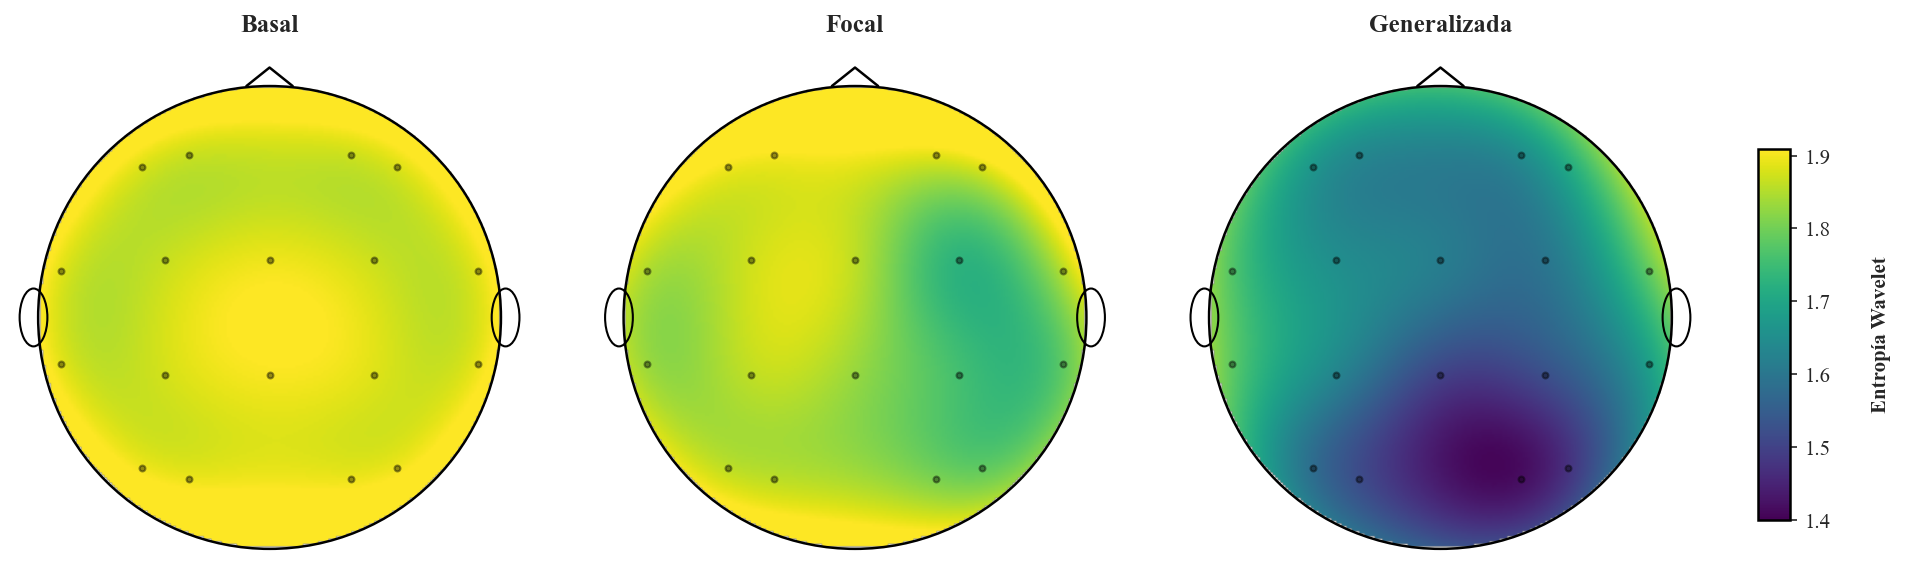

In [118]:
plot_topomap(df_sample, metric_suffix='_D2_ent', cbar_label='Entropía Wavelet')

Como se esperaba, los mapas de la corteza cerebral muestran que los niveles de entropía en el estado basal presentan los valores más altos, reflejando una actividad cortical asincrónica en la que las distintas redes neuronales procesan información de manera independiente. Por su parte, en las crisis focales se evidencia una disminución localizada de esta métrica —apreciable, por ejemplo, en el lóbulo derecho—, lo cual indica que un grupo específico de neuronas ha comenzado a descargar de forma sincrónica. Cabe destacar que la ubicación exacta de esta reducción varía según el foco epileptogénico de cada paciente. Finalmente, en las crisis generalizadas se observa una caída drástica y global de la entropía en toda la corteza. Este patrón revela que el cerebro ha perdido su complejidad funcional fisiológica, adoptando en su lugar una actividad eléctrica paroxística altamente sincrónica y predecible.

### Energía RMS (Banda D3 - Alpha Superior/Beta)

La métrica RMS (Root Mean Square) cuantifica la potencia media de la señal, proporcionando una medida de la amplitud de las oscilaciones en un nivel de resolución específico. En lugar de evaluar la complejidad, el RMS se enfoca en la intensidad de la actividad eléctrica tras la descomposición por la DWT. Matemáticamente, si definimos $C_{j,k}$ como los coeficientes Wavelet en el nivel de detalle $j$ (donde $j=3$ corresponde a las frecuencias medias de 16 a 32 Hz, asociadas a los ritmos Alpha superior y Beta), el valor RMS se calcula como la raíz cuadrada del promedio de los coeficientes al cuadrado:$$RMS(j) = \sqrt{\frac{1}{N} \sum_{k=1}^{N} |C_{j,k}|^2}$$En este contexto, la banda D3 actúa como un indicador de la reactividad cortical y la presencia de descargas paroxísticas de gran amplitud. Un valor RMS bajo en esta banda es característico de un estado basal saludable, donde la actividad eléctrica es de baja intensidad. Por el contrario, un incremento significativo en este valor durante un evento ictal revela la liberación masiva de energía eléctrica. Así, el RMS en el nivel D3 funciona como un sensor de la severidad de la descarga, permitiendo identificar la transición desde la actividad de fondo normal hacia las oscilaciones de alta amplitud que dominan el registro durante una crisis epiléptica.


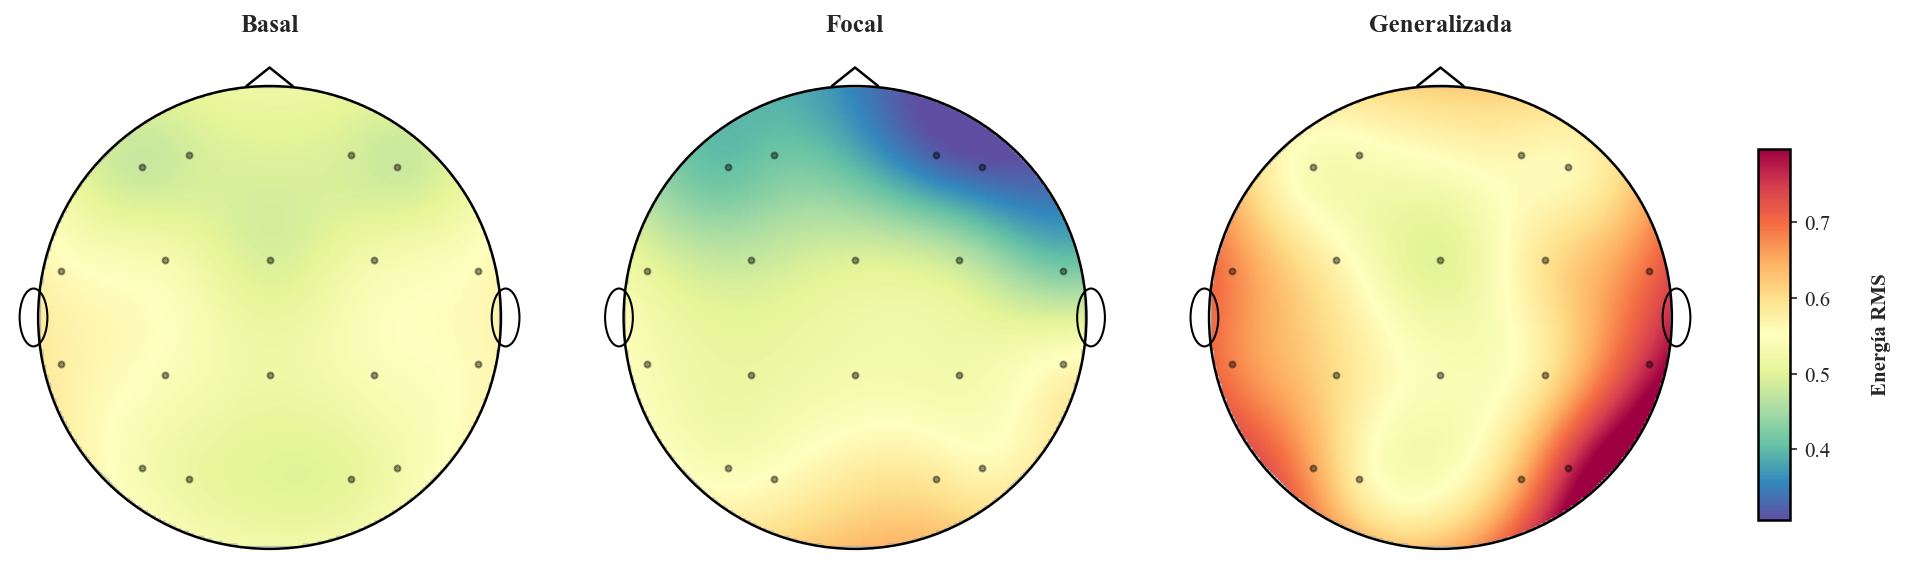

In [119]:
plot_topomap(df_sample, metric_suffix='_D3_rms', cbar_label='Energía RMS')

Como se observa en la distribución espacial, los niveles de RMS en el estado Basal se mantienen en rangos mínimos y uniformes (tonos amarillos claros), lo que confirma una actividad de fondo de baja amplitud sin componentes paroxísticos. En contraste, las Crisis Generalizadas presentan un incremento significativo y casi homogéneo de la métrica en toda la corteza, reflejando una descarga de gran amplitud que ha reclutado la totalidad de la red neuronal.

Sin embargo, el hallazgo más relevante ocurre en las Crisis Focales, donde se evidencia un gradiente de energía bien definido. A diferencia de la homogeneidad de las otras macroclases, el estado focal muestra un foco de activación moderada, pero resalta una zona de baja descarga (tonos azules) localizada en el lóbulo prefrontal derecho. Este fenómeno sugiere que, mientras ciertas regiones corticales aumentan su potencia debido al evento ictal, otras áreas mantienen o incluso reducen su actividad, permitiendo que la métrica RMS actúe como un biomarcador clave para identificar la asimetría y la localización del foco epileptogénico frente a la descarga global de una crisis generalizada.

:::{admonition} Nota Clínica: Correlato Fisiopatológico y Preservación de la Consciencia
:class: note

La presencia de un gradiente espacial en la macroclase focal, caracterizado por un foco de alta energía coexistiendo con regiones de baja descarga (como el lóbulo prefrontal derecho), constituye la firma neurofisiológica de estos eventos. Este patrón refleja la restricción anatómica de la descarga epileptiforme y la acción de mecanismos compensatorios activos, tales como la **inhibición circundante**, que suprimen la excitabilidad de las redes adyacentes para intentar contener la propagación de la hipersincronía ictal.

Clínicamente, la ausencia de reclutamiento en áreas críticas de asociación explica la capacidad de los pacientes para mantener el estado de alerta durante las **crisis focales con consciencia preservada**. Al no verse comprometidas por la descarga masiva, estas redes prefrontales y tálamo-corticales continúan ejecutando sus funciones cognitivas, estableciendo una diferencia fisiopatológica drástica frente a la disrupción global observada en los eventos generalizados.
:::

### Line Length (Banda D5 - Theta)

La métrica Line Length (LL) cuantifica la complejidad morfológica de una señal a través de la suma de las distancias euclidianas entre muestras sucesivas. A diferencia de las medidas de potencia tradicionales, el LL es sensible tanto a las variaciones de amplitud como a los cambios en la frecuencia de la oscilación. Matemáticamente, para un nivel de detalle $j$ resultante de la DWT (donde $j=5$ corresponde a la banda Theta de 4 a 8 Hz), el Line Length se define como:$$LL(j) = \sum_{k=1}^{N-1} |C_{j,k+1} - C_{j,k}|$$En este contexto, la banda D5 es de especial relevancia clínica, ya que el ritmo Theta es el sustrato principal de la lentificación rítmica y las descargas paroxísticas durante los eventos ictales. Un valor de LL bajo en esta banda indica una señal suave y de baja energía, propia del estado basal. Por el contrario, un incremento en el LL revela una señal con mayor "rugosidad" o dinamismo, característica de las espigas y ondas lentas de gran amplitud. Así, el Line Length en el nivel D5 actúa como un sensor de la actividad paroxística rítmica, permitiendo distinguir la morfología organizada de la crisis frente al ruido de fondo.


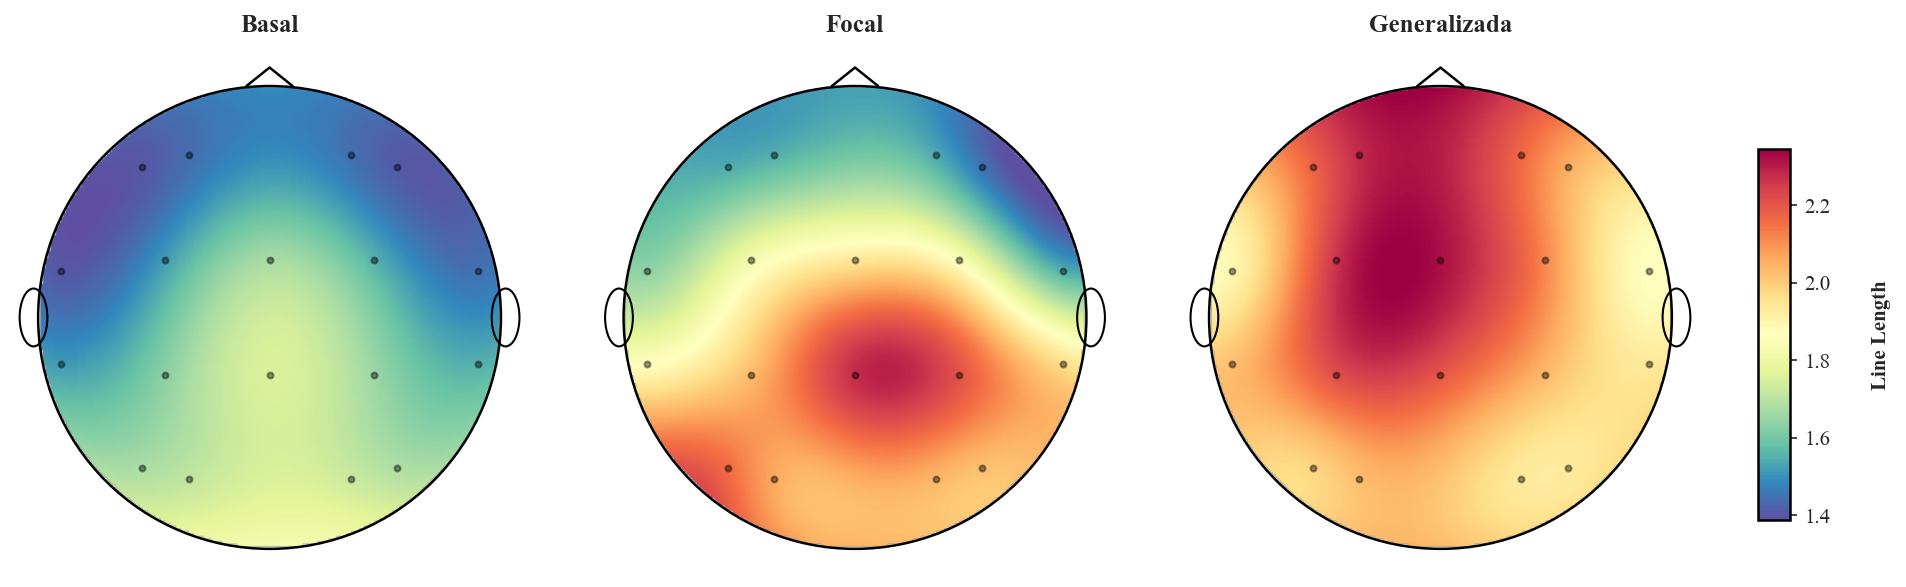

In [120]:
plot_topomap(df_sample, metric_suffix='_D5_ll', cbar_label='Line Length')

Como se observa en la distribución espacial, los niveles de Line Length en el estado Basal se mantienen en rangos mínimos (colores fríos), con una quietud morfológica especialmente marcada en el área prefrontal. Sin embargo, en las Crisis Focales se produce un contraste crítico: mientras que la corteza prefrontal permanece relativamente estable, la región parieto-temporo-occipital se activa de manera masiva. Este patrón visual evidencia cómo la descarga ictal distorsiona la morfología de la señal en las áreas posteriores del cerebro, mientras que las redes anteriores logran mantenerse al margen de la hipersincronía. Finalmente, en las Crisis Generalizadas, se pierde cualquier rastro de selectividad regional; la totalidad del manto cortical presenta valores elevados de LL, indicando que la actividad paroxística ha saturado globalmente el registro.

:::{admonition} Nota Clínica: Correlación Topográfica y Fenomenología Perceptiva
:class: note

La atenuación de la métrica **Line Length** en la región prefrontal durante los eventos focales guarda una estrecha relación anatómica con la preservación de los procesos cognitivos superiores. Al mantenerse mayoritariamente al margen de la descarga hipersincrónica, esta corteza logra sostener funciones ejecutivas críticas, en particular la atención y la memoria de trabajo. Este hallazgo es congruente con la dinámica observada en la energía RMS y refuerza el sustrato neurofisiológico subyacente a las crisis con consciencia preservada.

En contraste, la marcada activación de la **encrucijada parieto-temporo-occipital** representa un patrón de reclutamiento prominente dentro de los registros del corpus TUSZ. Dado que esta macrorregión posterior actúa como el principal centro de procesamiento e integración sensoperceptiva del cerebro, la distorsión morfológica de la señal en esta área explica directamente la fenomenología clínica de los eventos focales. Específicamente, esta hiperexcitabilidad cortical se correlaciona con las **auras y las alucinaciones sensoriales** (visuales, auditivas o somatosensoriales) frecuentemente reportadas por los pacientes durante el inicio y desarrollo de la crisis.
:::

# Análisis de Dependencia Monotónica e Independencia de Atributos

Tras caracterizar la distribución espacial y estadística de los atributos, se procedió a evaluar la relación de dependencia entre las variables seleccionadas. Debido a que las distribuciones morfológicas de los descriptores extraídos (especialmente en las bandas Gamma y Theta) no presentan una distribución normal y exhiben sesgos significativos, se descartó el uso del coeficiente de correlación de Pearson. En su lugar, se empleó el Coeficiente de Correlación de Rangos de Spearman ($\rho$), el cual evalúa la fuerza de una relación monotónica sin asumir linealidad, siendo menos sensible a los valores atípicos presentes en la señal de EEG.

Este análisis permite identificar el grado de redundancia entre los biomarcadores. Una correlación elevada entre dos variables indicaría que ambas capturan el mismo fenómeno neurofisiológico, mientras que una correlación moderada o baja confirma que los descriptores (como la Entropía, el RMS y el Line Length) proporcionan información complementaria sobre la dinámica ictal. A continuación, se presenta la matriz de correlación en forma de mapa de calor (heatmap) para el conjunto total de variables preseleccionadas:


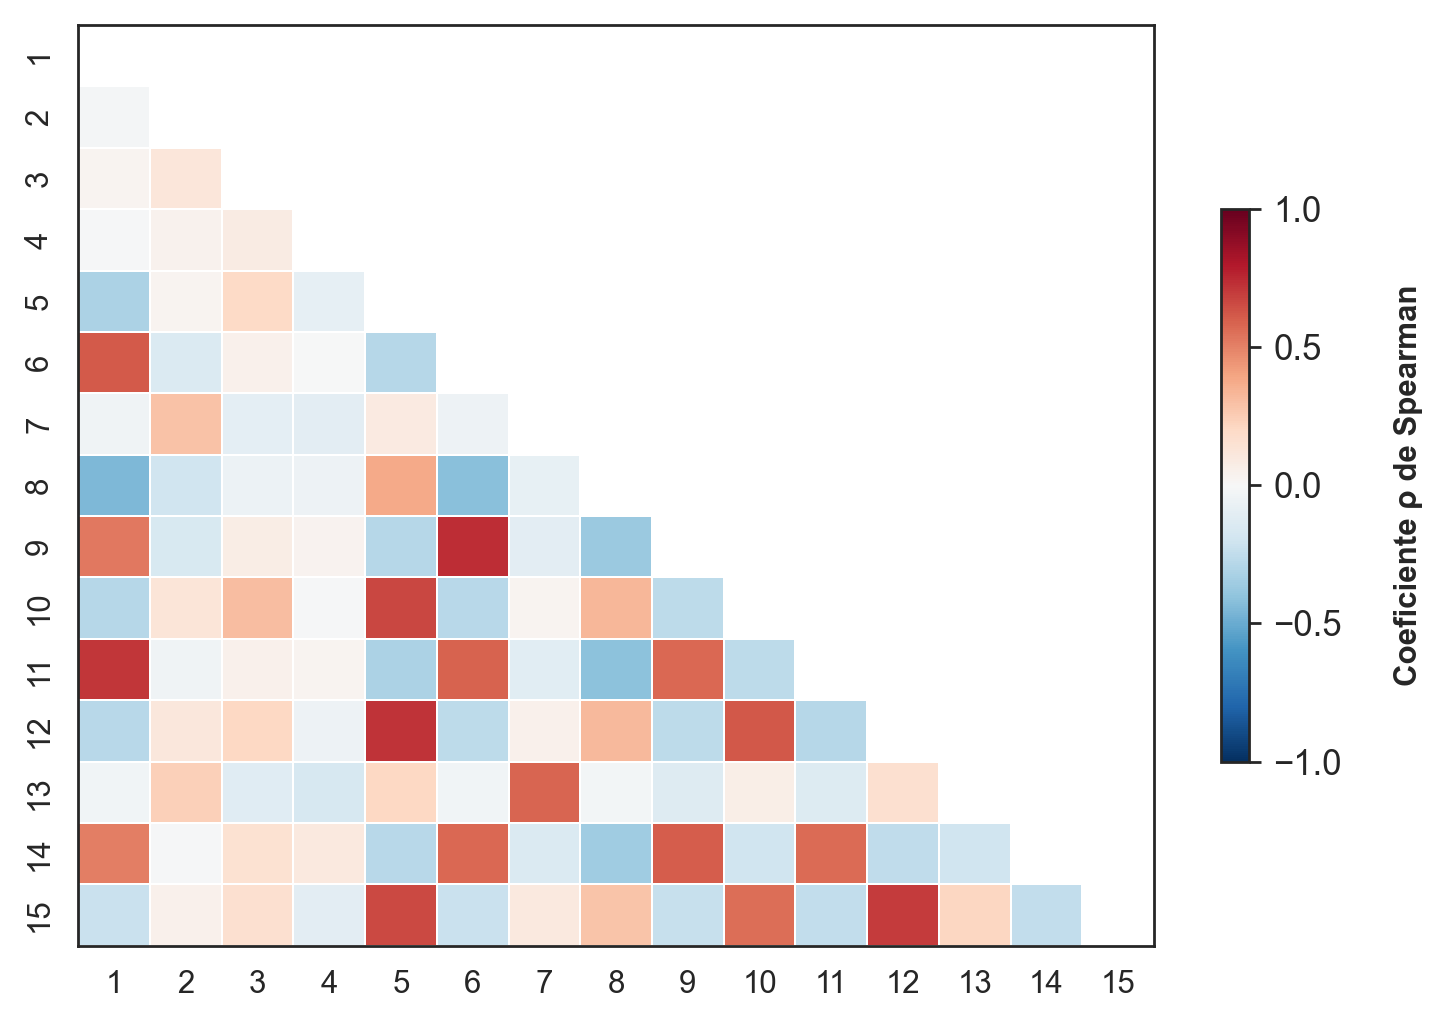

In [6]:
plot_spearman_heatmap(df_sample, ranking["Feature"])

Los resultados del análisis de correlación de Spearman revelan que la mayoría de las parejas de variables presentan coeficientes bajos o cercanos a cero, lo que confirma una independencia monotónica entre los descriptores extraídos. Este hallazgo es fundamental, ya que indica que métricas como la Entropía, el RMS y el Line Length capturan dimensiones distintas y complementarias de la señal ictal. No obstante, se observan asociaciones fuertes ($r > 0.8$) exclusivamente en aquellas variables que pertenecen a la misma banda de frecuencia y codifican información morfológica similar en canales anatómicamente cercanos; por ejemplo, la relación entre Fp1-F3_D5_ll (5) y Fp2-F8_D5_ll (15). Esta dependencia era de esperarse, dado que ambos canales registran la actividad de la corteza prefrontal en la banda Theta, capturando variaciones morfológicas altamente consistentes durante la propagación de la descarga. En conjunto, la matriz sugiere un conjunto de datos robusto y diversificado, donde la redundancia es mínima y está justificada neurofisiológicamente.

# Análisis de Componentes Principales (PCA) y Espacio de Características

Debido a los hallazgos de dependencia monotónica entre ciertas variables —particularmente aquellas que comparten banda de frecuencia y cercanía anatómica—, se procedió a realizar un Análisis de Componentes Principales (PCA). El propósito de esta técnica es transformar el conjunto original de variables correlacionadas en un nuevo sistema de coordenadas ortogonales, eliminando la redundancia y permitiendo observar cómo se distribuyen las macroclases de crisis en un espacio de características optimizado.

A continuación, se presenta la curva de varianza acumulada, la cual permite determinar cuánta información del conjunto de datos original es retenida por cada componente principal. Posteriormente, se muestra la proyección bidimensional de las muestras, facilitando la identificación visual de agrupamientos (clusters) y el grado de separabilidad entre los estados basal, focal y generalizado en el espacio latente.


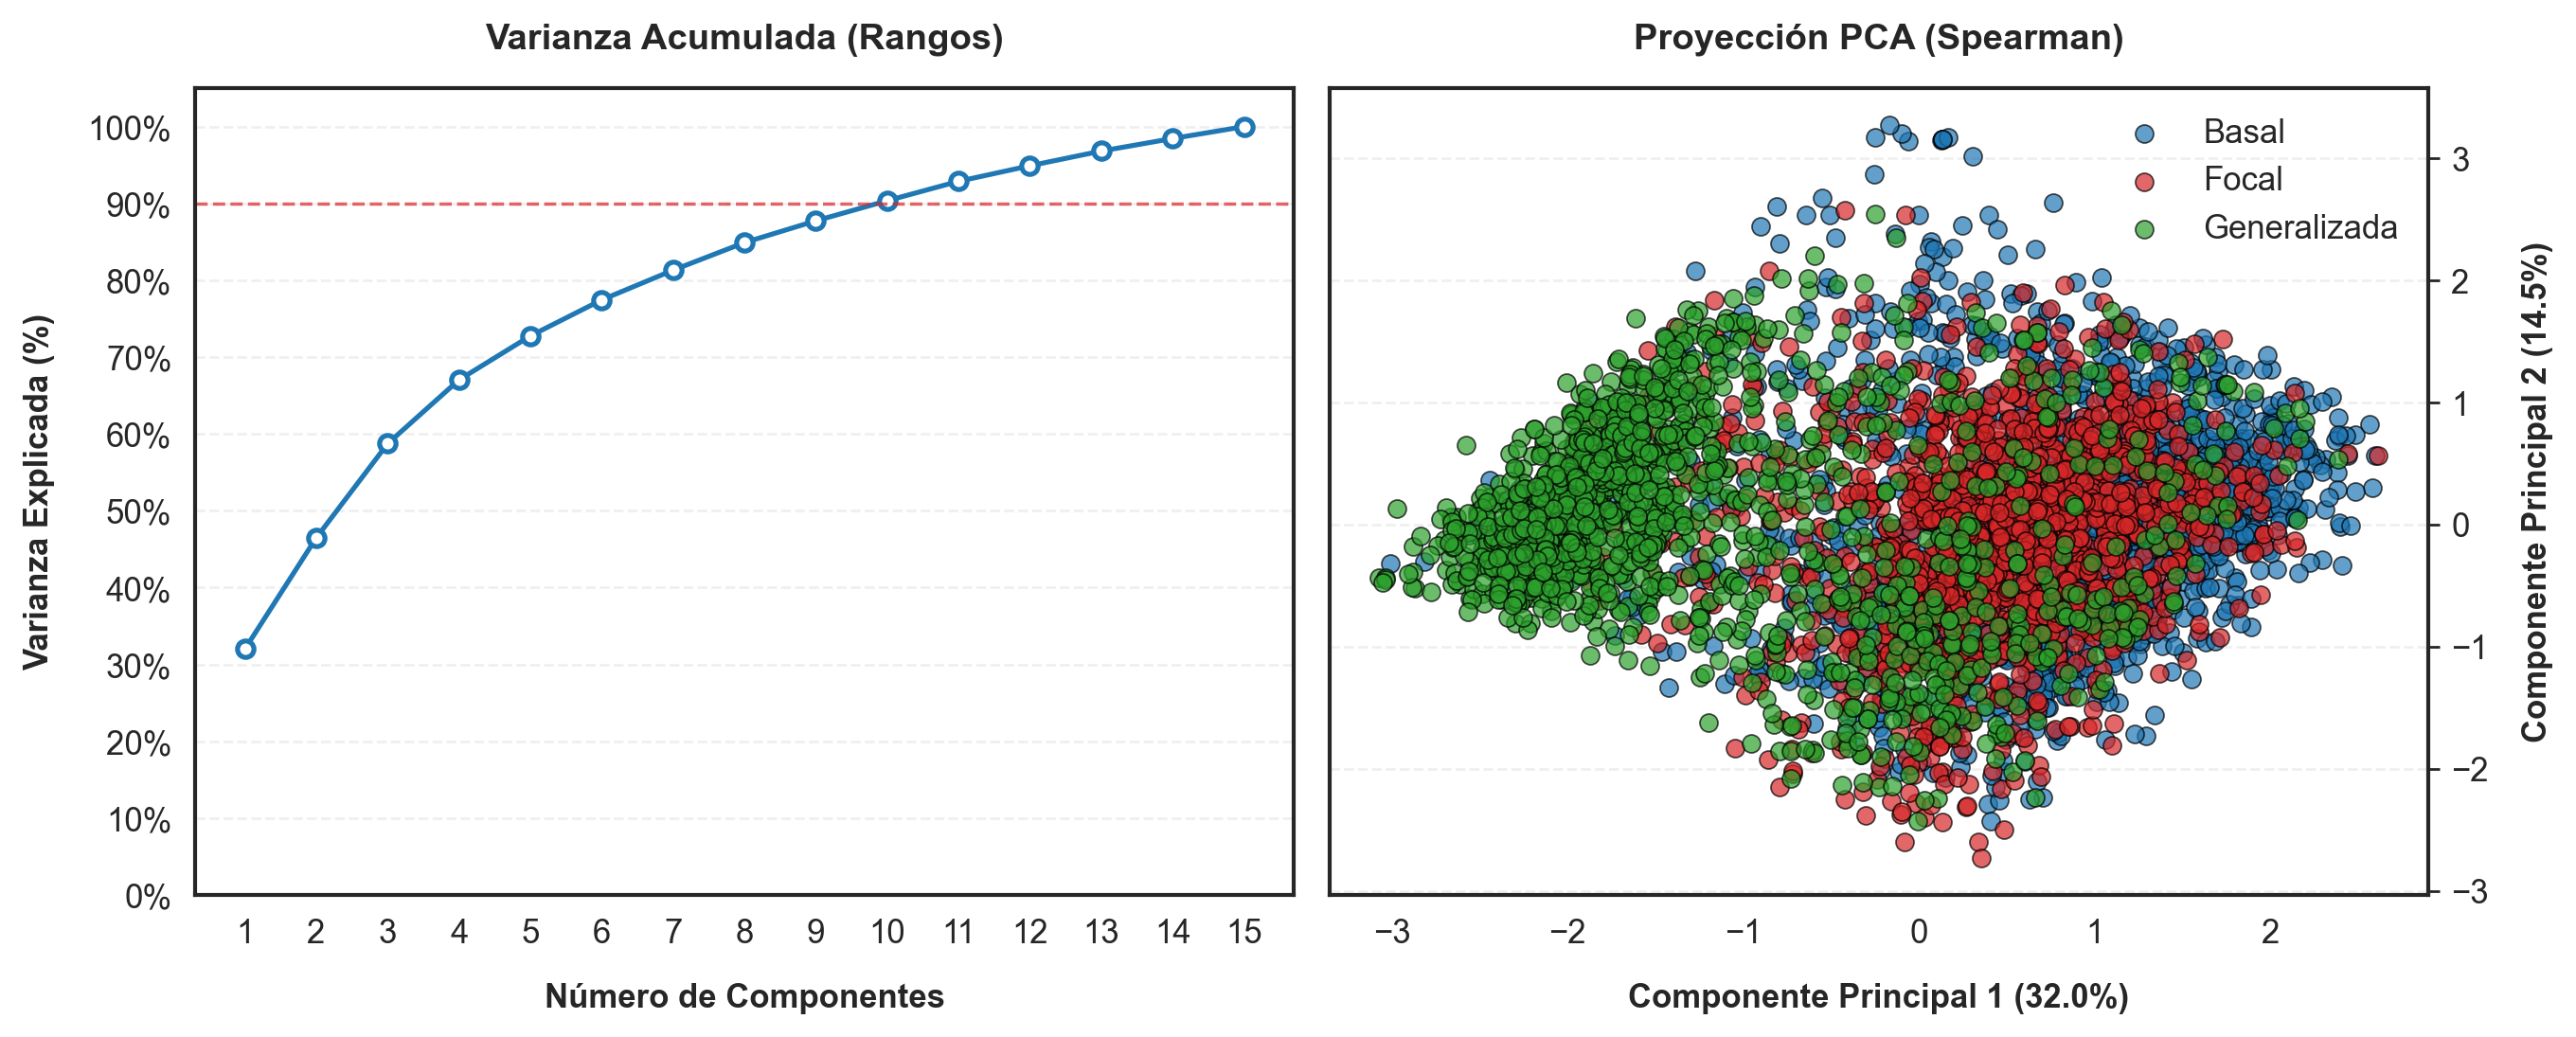

In [7]:
plot_pca_rank(df_sample, ranking["Feature"])

La visualización del PCA revela una estructura compleja en el espacio de características. En primer lugar, la curva de varianza acumulada indica que las tres primeras componentes principales solo capturan aproximadamente el 60% de la varianza total. Esta dispersión es un resultado esperado, ya que gran parte de los atributos extraídos son monotónicamente independientes; al no existir una redundancia lineal dominante, la información se distribuye en múltiples dimensiones, lo que impide simplificar la dinámica ictal en unos pocos componentes.

Por otro lado, la proyección bidimensional en el espacio latente muestra un solapamiento considerable entre las tres macroclases (basal, focal y generalizada). Esta falta de separabilidad no implica la ausencia de patrones discriminatorios, sino que confirma que las fronteras de decisión entre los estados ictales son intrínsecamente no lineales. Lejos de ser un resultado desfavorable, esta observación justifica la implementación de modelos de clasificación avanzados, capaces de identificar las relaciones complejas y jerárquicas que una técnica de reducción de dimensionalidad lineal no logra desentrañar.

:::{admonition} Nota Metodológica: PCA Basado en Rangos
:class: note

Aunque el Análisis de Componentes Principales (PCA) se formula tradicionalmente a partir de la matriz de covarianza —asumiendo, por ende, una estructura de dependencia lineal entre los atributos—, en este estudio la proyección latente se construyó tomando como punto de partida la matriz de correlación de rangos de Spearman. Esta adaptación metodológica altera sutilmente la interpretación clásica del espacio resultante: los componentes extraídos ya no maximizan la varianza lineal común, sino una dispersión o varianza basada estrictamente en el orden de los rangos.

La implementación de este enfoque proporciona una ventaja analítica sustancial. Al fundamentarse en rangos, la transformación se vuelve significativamente más robusta frente a la presencia de valores atípicos (*outliers*) y artefactos transitorios, característicos de las señales de EEG. Esto garantiza que la topología observada en el espacio de características, incluyendo el grado de solapamiento entre las macroclases, sea un reflejo fiel de la compleja dinámica neurofisiológica y no el producto de distorsiones generadas por datos extremos.
:::

Dadas las limitaciones intrínsecas del PCA para resolver el solapamiento entre las macroclases en un espacio lineal, se optó por emplear algoritmos de visualización no lineales. Específicamente, se utilizó la técnica UMAP (Uniform Manifold Approximation and Projection) con el objetivo de determinar si los estados basal, focal y generalizado poseen una estructura topológica subyacente más definida en un espacio de baja dimensionalidad.Para este análisis, se evaluaron dos métricas de proximidad fundamentales que determinan cómo se calcula la cercanía entre los puntos del espacio de características:

* **Distancia Euclidiana:** Mide la magnitud lineal recta entre dos puntos:$$d(x,y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

* **Distancia Coseno:** Cuantifica la similitud orientacional entre vectores, siendo insensible a su magnitud:$$d_{cos}(\mathbf{X},\mathbf{Y}) = 1 - \frac{\mathbf{X} \cdot \mathbf{Y}}{\|\mathbf{X}\| \|\mathbf{Y}\|}$$

El uso de ambas métricas permitió identificar cuál captura con mayor fidelidad la estructura de las señales, considerando que el EEG presenta una alta variabilidad en amplitud pero mantiene patrones direccionales consistentes durante los eventos ictales. A continuación, se presenta la proyección de las muestras en el espacio latente de UMAP, donde se evalúa si la redistribución de los datos permite una mejor discriminación visual de la taxonomía de las crisis:

:::{admonition} Nota Metodológica: UMAP en la Proyección del Espacio de Características
:class: note

El algoritmo de Aproximación y Proyección Uniforme de Variedades (**UMAP**, por sus siglas en inglés) es una técnica de reducción de dimensionalidad no lineal. Su arquitectura se fundamenta en la topología algebraica y la geometría Riemanniana, modelando la distribución espacial de los datos de alta dimensionalidad a través de grafos difusos (*fuzzy simplicial sets*).

Si bien otras técnicas de incrustación estocástica como **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*) han sido empleadas en la literatura reciente para abordar la taxonomía de crisis epilépticas a partir de señales de EEG ([Padmaja et al., 2026](https://doi.org/10.1038/s41598-026-36121-0)), UMAP presenta ventajas analíticas críticas. Mientras t-SNE prioriza la preservación de vecindarios locales —frecuentemente a expensas de distorsionar la estructura macroscópica del espacio latente—, UMAP logra un equilibrio matemático riguroso que retiene tanto la topología local como la global. 

En consecuencia, las distancias relativas entre distintos agrupamientos en la proyección resultante poseen un significado interpretativo real, lo cual resulta vital para mapear con precisión trayectorias continuas o transiciones entre estados neurofisiológicos. Los fundamentos teóricos de esta aproximación se encuentran detallados en la [documentación oficial de UMAP (McInnes et al., 2018)](https://umap-learn.readthedocs.io/en/latest/index.html).
:::


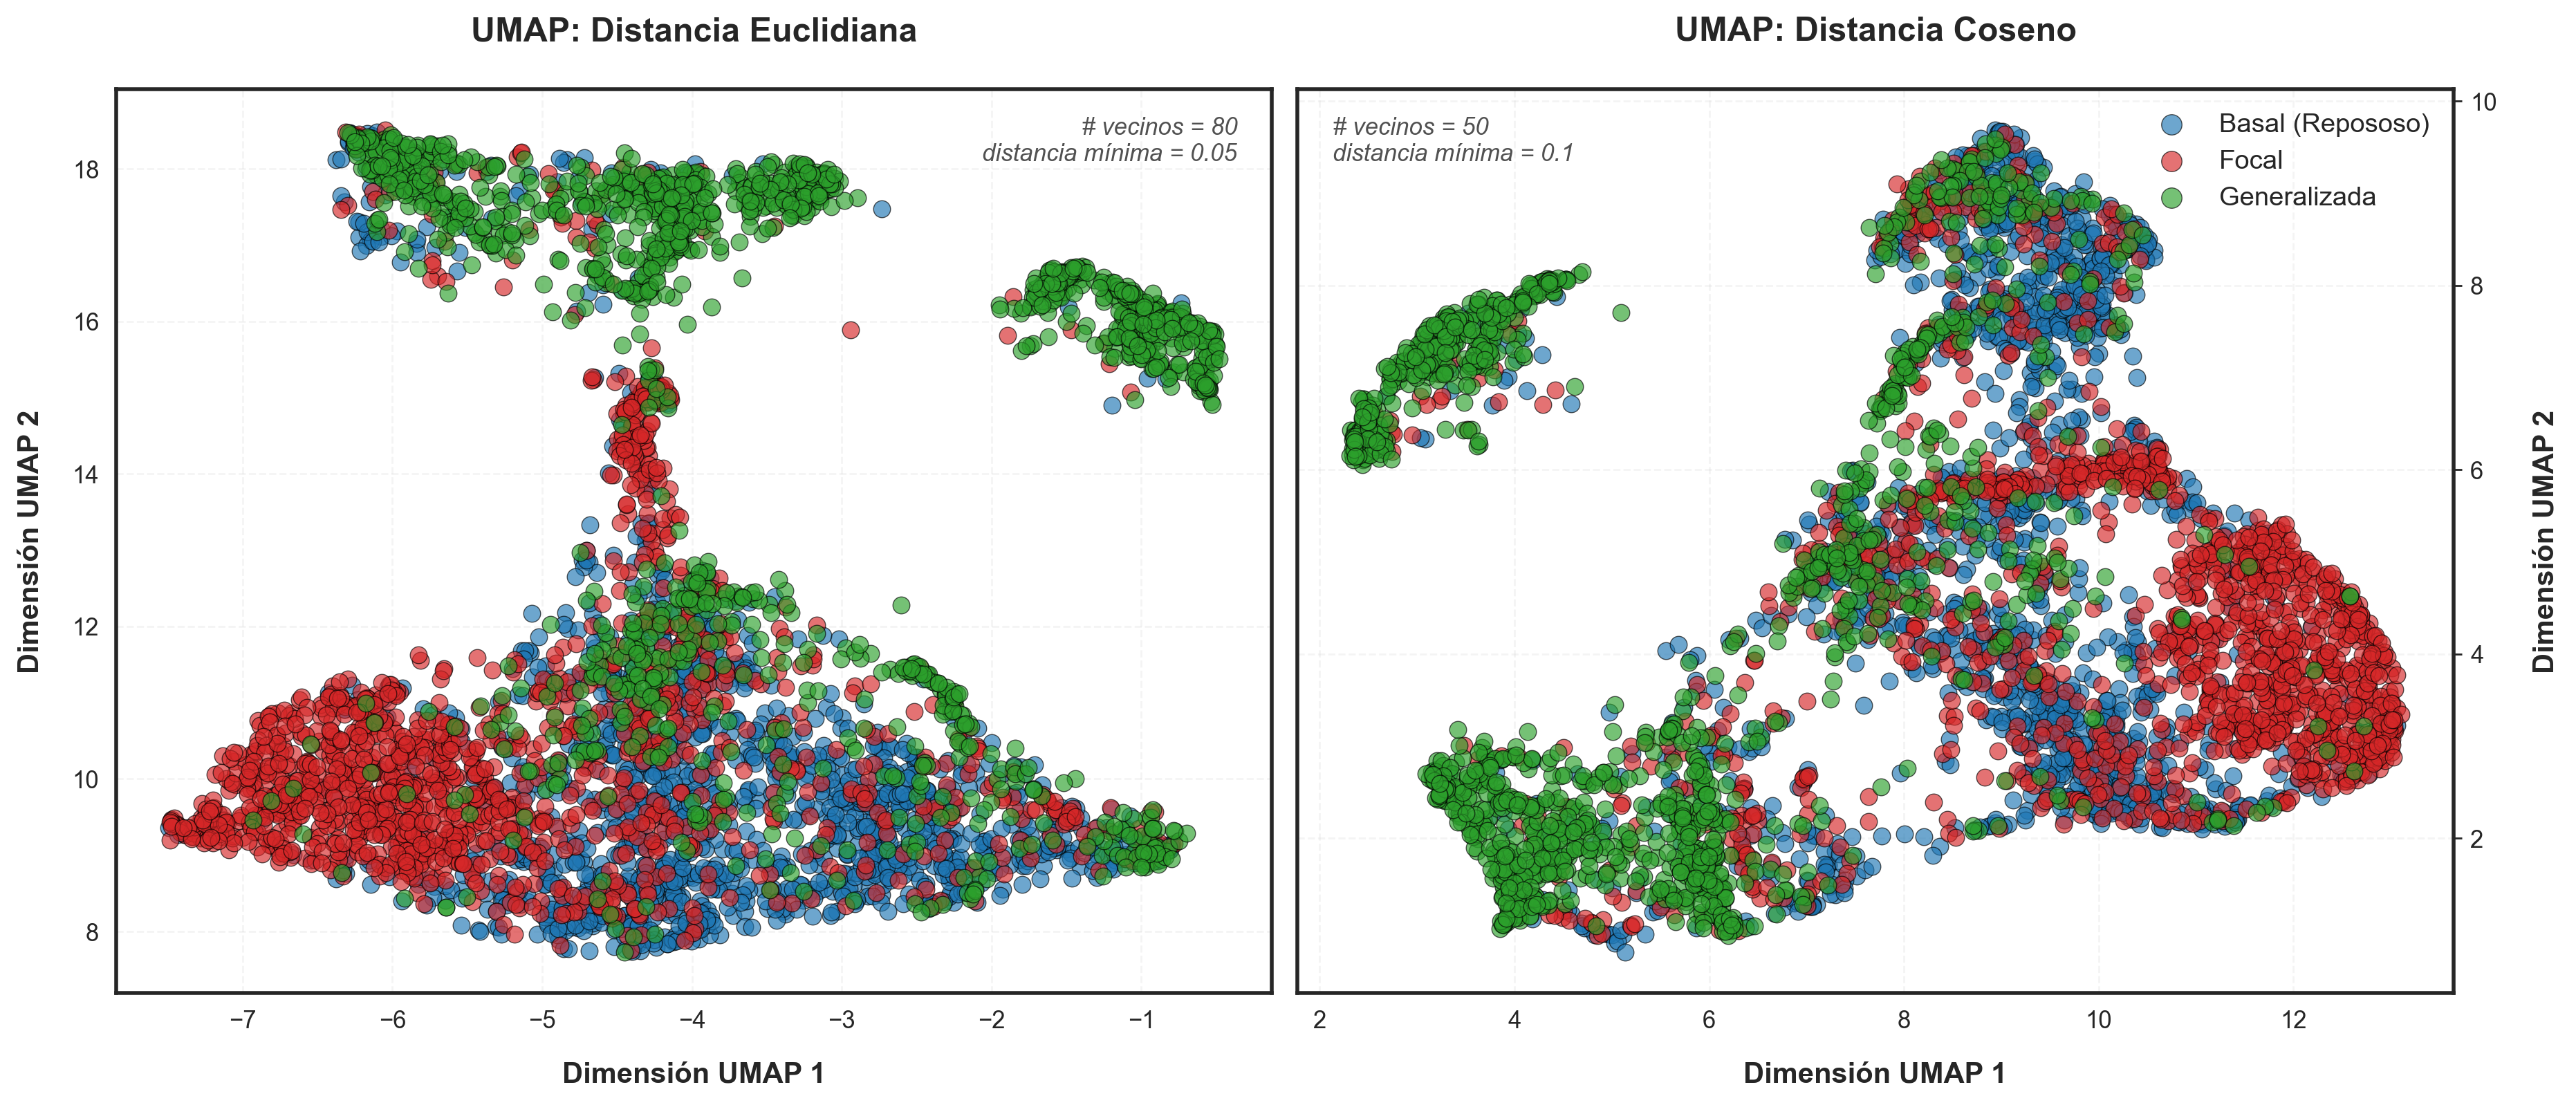

In [8]:
plot_umap(df_sample, ranking["Feature"])

La proyección no lineal mediante UMAP demuestra que la métrica de distancia coseno es superior a la euclidiana para revelar la topología latente del corpus. En este espacio, el estado basal se concentra en la región central conformando un núcleo fisiológico, desde el cual los eventos ictales se proyectan hacia la periferia. Mientras que las crisis focales estructuran una "península" cohesiva que evidencia una alta consistencia morfológica, la macroclase generalizada exhibe una marcada heterogeneidad espacial al ramificarse en dos brazos —uno inferior dominado por crisis de ausencia y uno superior clínicamente más variado— junto con un "islote" aislado que corresponde exclusivamente a las crisis generalizadas no específicas (GNSZ), reflejando con precisión las divergencias fisiopatológicas subyacentes entre las sub-etiquetas clínicas.

A pesar de la valiosa información topológica obtenida en la proyección bidimensional, la densidad y distribución de los agrupamientos sugieren que la separabilidad de las clases se optimizaría al añadir un eje adicional. Por consiguiente, se procedió a visualizar el espacio latente de UMAP en tres dimensiones. Como era de esperarse, esta extensión demostró ser la decisión metodológica más acertada para desenredar las zonas de solapamiento residual; en este nuevo espacio volumétrico, se evidencian áreas claramente dominadas por cada una de las macroclases ictales. Particularmente, el estado basal se posiciona de manera estratégica en el centro de la proyección, actuando morfológicamente como un puente transicional que conecta de forma continua la actividad de fondo normal con las respectivas trayectorias patológicas de las crisis focales y generalizadas.

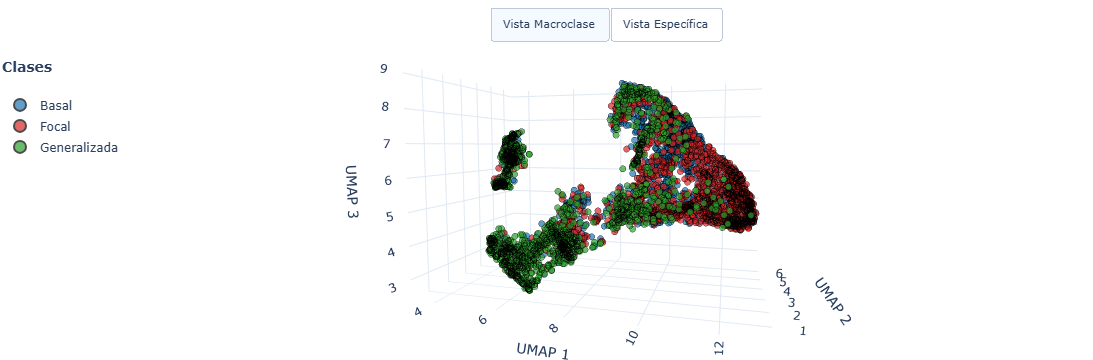

In [5]:
cols_a_excluir = ['partition_id', 'win_start_sec', 'label', 'patient_id']
df_3D = df_re.drop(columns=[c for c in cols_a_excluir if c in df_3D.columns])
plot_umap_3d(df_3D, top_features = ranking["Feature"].tolist(), macro_col='macro_class', specific_col='original_class')